### Healthcare payment analysis
* **Goal: Analysis of gender based payment disparity in pharmaceutical industry**
* **Scope Research data, Phase 2 - pilot case Top level analysis of industry**

* Date: 21 oct 2024


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Importing master dataset
df_research= pd.read_csv('Master_data_research_with_gender_clean_11_Nov.csv', index_col='Unnamed: 0', low_memory=False)


In [4]:
df_research.head()

,Covered_Recipient_Type,Noncovered_Recipient_Entity_Name,Teaching_Hospital_Name,Covered_Recipient_Profile_ID,Covered_Recipient_First_Name,Covered_Recipient_Last_Name,Recipient_State,Recipient_Country,Covered_Recipient_Primary_Type_1,Covered_Recipient_Specialty_1,...,Name_of_Study,ClinicalTrials_Gov_Identifier,Research_Information_Link,Context_of_Research,Covered_Recipient_gender,Principal_Investigator_5_gender,Principal_Investigator_4_gender,Principal_Investigator_3_gender,Principal_Investigator_2_gender,Principal_Investigator_1_gender
0,Covered Recipient Teaching Hospital,NaN,northshore university healthsystem,NaN,NaN,NaN,IL,united states,NaN,NaN,...,open-label extension study to evaluate the lon...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M
1,Covered Recipient Teaching Hospital,NaN,dell childrens medical center,NaN,NaN,NaN,TX,united states,NaN,NaN,...,"a randomized, double-blind, placebo-controlled...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F
2,Covered Recipient Non-Physician Practitioner,NaN,NaN,452304.0,connie,romaine,LA,united states,Nurse Practitioner,physician assistants & advanced practice nursi...,...,NaN,NaN,NaN,NaN,F,NaN,NaN,NaN,NaN,NaN
3,Covered Recipient Teaching Hospital,NaN,ohsu hospital and clinics,NaN,NaN,NaN,OR,united states,NaN,NaN,...,a prospective observational study to evaluate ...,NaN,NaN,h20-012,NaN,NaN,NaN,NaN,NaN,F
4,Covered Recipient Teaching Hospital,NaN,maryland general hospital,NaN,NaN,NaN,MD,united states,NaN,NaN,...,fine-real,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F


In [5]:
col_names=df_research.columns 

In [6]:
# Displaying all the columns

l1=list(enumerate(col_names))
for i,j in l1:
    print(j)

Covered_Recipient_Type
Noncovered_Recipient_Entity_Name
Teaching_Hospital_Name
Covered_Recipient_Profile_ID
Covered_Recipient_First_Name
Covered_Recipient_Last_Name
Recipient_State
Recipient_Country
Covered_Recipient_Primary_Type_1
Covered_Recipient_Specialty_1
Principal_Investigator_1_Covered_Recipient_Type
Principal_Investigator_1_Profile_ID
Principal_Investigator_1_First_Name
Principal_Investigator_1_Last_Name
Principal_Investigator_1_State
Principal_Investigator_1_Country
Principal_Investigator_1_Primary_Type_1
Principal_Investigator_1_Specialty_1
Principal_Investigator_2_Covered_Recipient_Type
Principal_Investigator_2_Profile_ID
Principal_Investigator_2_First_Name
Principal_Investigator_2_Last_Name
Principal_Investigator_2_State
Principal_Investigator_2_Country
Principal_Investigator_2_Primary_Type_1
Principal_Investigator_2_Specialty_1
Principal_Investigator_3_Covered_Recipient_Type
Principal_Investigator_3_Profile_ID
Principal_Investigator_3_First_Name
Principal_Investigator_3_L

In [7]:
df_research.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1028472 entries, 0 to 1028471
Columns: 107 entries, Covered_Recipient_Type to Principal_Investigator_1_gender
dtypes: float64(9), int64(1), object(97)
memory usage: 847.4+ MB


In [7]:
# Converting all id to string.
for i in ['Covered_Recipient_Profile_ID','Principal_Investigator_1_Profile_ID', 
         'Principal_Investigator_2_Profile_ID','Principal_Investigator_3_Profile_ID',
         'Principal_Investigator_4_Profile_ID','Principal_Investigator_5_Profile_ID',
         'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_ID', 
         'Associated_Device_or_Medical_Supply_PDI_4', 'Associated_Device_or_Medical_Supply_PDI_5']:
    msk = df_research[i].notna()
    df_research.loc[msk, i] = df_research.loc[msk, i].astype(str)
    

In [8]:
df_research['Covered_Recipient_Profile_ID'].nunique()

5662

In [ ]:
df_research.describe().applymap('{:,.2f}'.format)

,Total_Amount_of_Payment_USDollars
count,"1,028,472.00"
mean,"7,896.24"
std,"70,670.15"
min,0.01
25%,76.02
50%,742.44
75%,"2,675.33"
max,"13,607,486.88"


In [10]:
# Statitical description of all object types

df_research.describe(include='object')

,Covered_Recipient_Type,Noncovered_Recipient_Entity_Name,Teaching_Hospital_Name,Covered_Recipient_Profile_ID,Covered_Recipient_First_Name,Covered_Recipient_Last_Name,Recipient_State,Recipient_Country,Covered_Recipient_Primary_Type_1,Covered_Recipient_Specialty_1,...,Name_of_Study,ClinicalTrials_Gov_Identifier,Research_Information_Link,Context_of_Research,Covered_Recipient_gender,Principal_Investigator_5_gender,Principal_Investigator_4_gender,Principal_Investigator_3_gender,Principal_Investigator_2_gender,Principal_Investigator_1_gender
count,1028472,888712,113385,26305,26305,26305,1028090,1028402,26305,26305,...,1023118,490620,25725,119495,26305,43,94,251,2172,997339
unique,5,23932,666,5662,2201,4389,52,9,10,190,...,16718,2109,355,4733,2,2,2,2,2,2
top,Non-covered Recipient Entity,"clinedge, llc - ppds",ut md anderson cancer center,303222.0,david,giedd,FL,united states,Medical Doctor,allopathic & osteopathic physicians|psychiatry...,...,"a phase 3, randomized, observer-blind, active-...",NCT05566639,https://clinicaltrials.gov/ct2/show/NCT0498720...,payments or transfers of value related to rese...,M,M,M,M,M,M
freq,888712,43688,5217,295,783,295,169479,1028090,23843,2437,...,130147,130147,1914,21260,18248,38,74,207,1748,743011


In [11]:
print("Total payments processed in reaserch activies in 2023:", df_research['Total_Amount_of_Payment_USDollars'].sum().round())



Total payments processed in reaserch activies in 2023: 8121059045.0


In [12]:
# Function to create univariate charts

def create_chart(df, col_name, description):
    plt.title(description)
    # df[col_name].value_counts().plot(kind='barh')
    print(df[col_name].value_counts(), '\n')
    sns.barplot(data=df[col_name].value_counts().reset_index(), x=col_name, y='count', hue=col_name);
    


###  6 name columns, the covered recipients, 5 investigators. The gender columns for all these.

Covered_Recipient_gender
M    18248
F     8057
Name: count, dtype: int64 



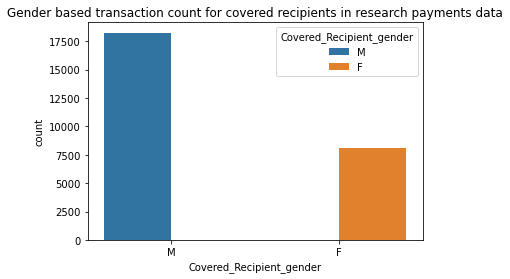

In [13]:
create_chart(df_research, 'Covered_Recipient_gender', 'Gender based transaction count for covered recipients in research payments data' )


Principal_Investigator_1_gender
M    743011
F    254328
Name: count, dtype: int64 



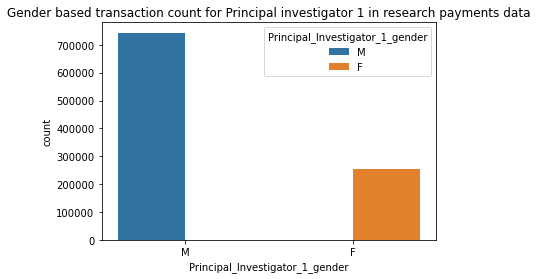

In [14]:
create_chart(df_research, 'Principal_Investigator_1_gender', 'Gender based transaction count for Principal investigator 1 in research payments data')


Principal_Investigator_2_gender
M    1748
F     424
Name: count, dtype: int64 



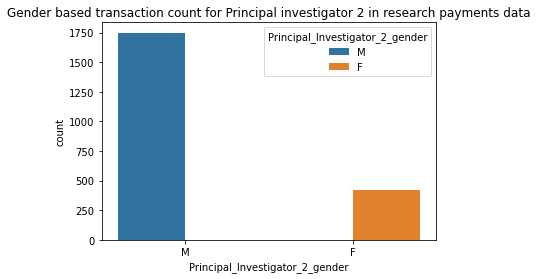

In [15]:
create_chart(df_research, 'Principal_Investigator_2_gender', 'Gender based transaction count for Principal investigator 2 in research payments data')

Principal_Investigator_3_gender
M    207
F     44
Name: count, dtype: int64 



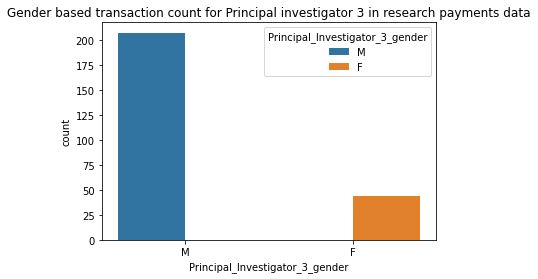

In [16]:
create_chart(df_research, 'Principal_Investigator_3_gender', 'Gender based transaction count for Principal investigator 3 in research payments data')

Principal_Investigator_4_gender
M    74
F    20
Name: count, dtype: int64 



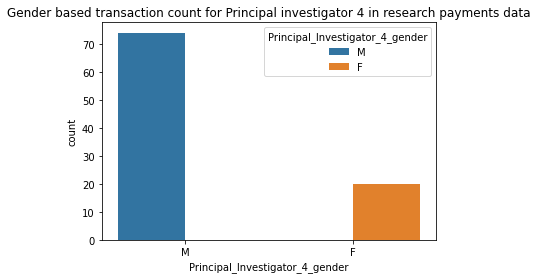

In [17]:
create_chart(df_research, 'Principal_Investigator_4_gender','Gender based transaction count for Principal investigator 4 in research payments data')


Principal_Investigator_5_gender
M    38
F     5
Name: count, dtype: int64 



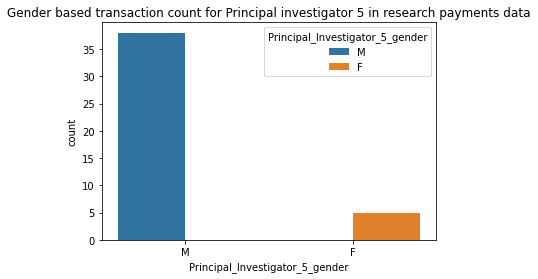

In [18]:
create_chart(df_research, 'Principal_Investigator_5_gender','Gender based transaction count for Principal investigator 5 in research payments data')


## Gender based count by profile ID

In [19]:
# Function to create charts by profile IDs

def create_chart_bygender(df, col1, col2, col3, description):
    my_palette ={"F":'orange', "M": 'blue'}
    plt.title(description)
    g=sns.barplot(data=df, x=col1, y=col2, hue=col3, palette=my_palette);
    plt.ylabel("Count")
    # Place the legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    g.figure.set_size_inches(7, 4);
    

In [20]:
print("Gender distribution by recipients in healthcare research")
gender_dist_recipients=df_research.groupby(['Covered_Recipient_Type','Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index()
gender_dist_recipients

Gender distribution by recipients in healthcare research


,Covered_Recipient_Type,Covered_Recipient_gender,Covered_Recipient_Profile_ID
0,Covered Recipient Non-Physician Practitioner,F,170
1,Covered Recipient Non-Physician Practitioner,M,56
2,Covered Recipient Physician,F,1573
3,Covered Recipient Physician,M,3864


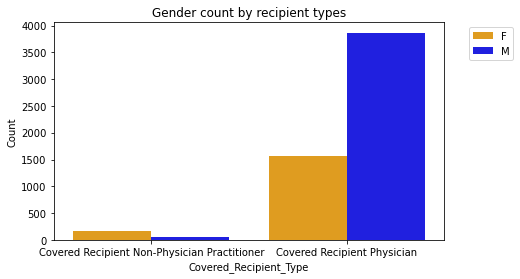

In [21]:
# Plot using the function
create_chart_bygender(gender_dist_recipients, 'Covered_Recipient_Type', 'Covered_Recipient_Profile_ID','Covered_Recipient_gender', "Gender count by recipient types") 



In [22]:
print("Gender distribution by principal investigators in healthcare research")
gender_dist_PI1=df_research.groupby(['Principal_Investigator_1_gender'])['Principal_Investigator_1_Profile_ID'].nunique().reset_index()
gender_dist_PI1


Gender distribution by principal investigators in healthcare research


,Principal_Investigator_1_gender,Principal_Investigator_1_Profile_ID
0,F,8419
1,M,21570


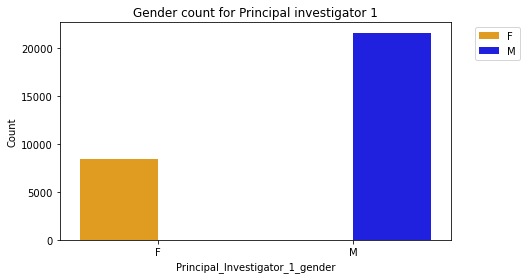

In [23]:
# Plot using the function
create_chart_bygender(gender_dist_PI1, 'Principal_Investigator_1_gender', 'Principal_Investigator_1_Profile_ID','Principal_Investigator_1_gender', "Gender count for Principal investigator 1") 


In [24]:
print("Gender distribution by principal investigators 2 in healthcare research")
gender_dist_PI2=df_research.groupby(['Principal_Investigator_2_gender'])['Principal_Investigator_2_Profile_ID'].nunique().reset_index()
gender_dist_PI2


Gender distribution by principal investigators 2 in healthcare research


,Principal_Investigator_2_gender,Principal_Investigator_2_Profile_ID
0,F,130
1,M,402


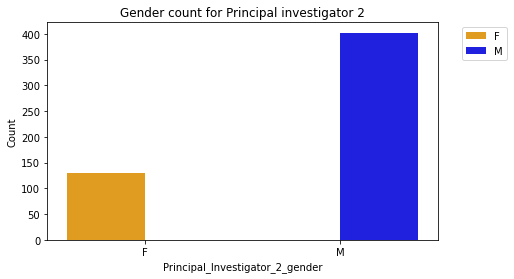

In [25]:
# Plot using the function
create_chart_bygender(gender_dist_PI2, 'Principal_Investigator_2_gender', 'Principal_Investigator_2_Profile_ID','Principal_Investigator_2_gender', "Gender count for Principal investigator 2") 


In [26]:
print("Gender distribution by principal investigators 3 in healthcare research")
gender_dist_PI3=df_research.groupby(['Principal_Investigator_3_gender'])['Principal_Investigator_3_Profile_ID'].nunique().reset_index()
gender_dist_PI3

Gender distribution by principal investigators 3 in healthcare research


,Principal_Investigator_3_gender,Principal_Investigator_3_Profile_ID
0,F,16
1,M,69


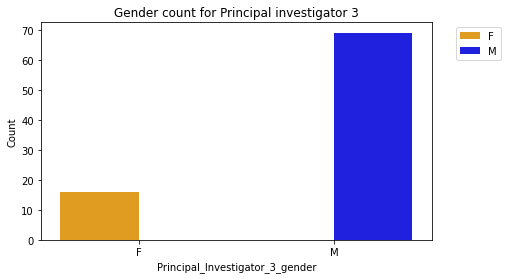

In [27]:
# Plot using the function
create_chart_bygender(gender_dist_PI3, 'Principal_Investigator_3_gender', 'Principal_Investigator_3_Profile_ID','Principal_Investigator_3_gender', "Gender count for Principal investigator 3") 


In [28]:
print("Gender distribution by principal investigators 4 in healthcare research")
gender_dist_PI4=df_research.groupby(['Principal_Investigator_4_gender'])['Principal_Investigator_4_Profile_ID'].nunique().reset_index()
gender_dist_PI4

Gender distribution by principal investigators 4 in healthcare research


,Principal_Investigator_4_gender,Principal_Investigator_4_Profile_ID
0,F,7
1,M,27


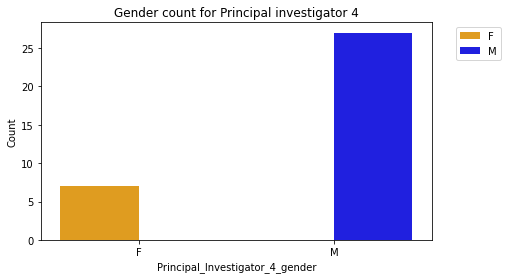

In [29]:
# Plot using the function
create_chart_bygender(gender_dist_PI4, 'Principal_Investigator_4_gender', 'Principal_Investigator_4_Profile_ID','Principal_Investigator_4_gender', "Gender count for Principal investigator 4") 


In [30]:
print("Gender distribution by principal investigators 5 in healthcare research")
gender_dist_PI5=df_research.groupby(['Principal_Investigator_5_gender'])['Principal_Investigator_5_Profile_ID'].nunique().reset_index()
gender_dist_PI5

Gender distribution by principal investigators 5 in healthcare research


,Principal_Investigator_5_gender,Principal_Investigator_5_Profile_ID
0,F,5
1,M,16


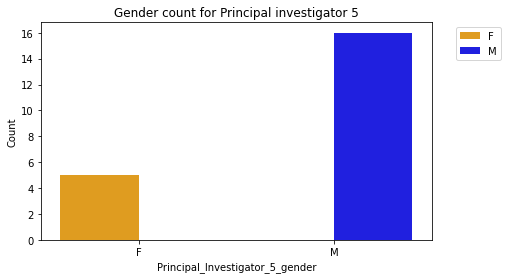

In [31]:
# Plot using the function
create_chart_bygender(gender_dist_PI5, 'Principal_Investigator_5_gender', 'Principal_Investigator_5_Profile_ID','Principal_Investigator_5_gender', "Gender count for Principal investigator 5") 


### Understanding payment related features
* Total_Amount_of_Payment_USDollars
* Form_of_Payment_or_Transfer_of_Value
* Expenditure_Category1
* Expenditure_Category2
* Expenditure_Category3
* Expenditure_Category4
* Expenditure_Category5
* Expenditure_Category6

In [32]:
df_research[['Total_Amount_of_Payment_USDollars','Form_of_Payment_or_Transfer_of_Value',
             'Expenditure_Category1','Expenditure_Category2','Expenditure_Category3',
             'Expenditure_Category4','Expenditure_Category5','Expenditure_Category6']]

,Total_Amount_of_Payment_USDollars,Form_of_Payment_or_Transfer_of_Value,Expenditure_Category1,Expenditure_Category2,Expenditure_Category3,Expenditure_Category4,Expenditure_Category5,Expenditure_Category6
0,1632.00,Cash or cash equivalent,NaN,NaN,NaN,NaN,NaN,NaN
1,8.67,Cash or cash equivalent,NaN,NaN,NaN,NaN,NaN,NaN
2,395.22,In-kind items and services,NaN,NaN,NaN,NaN,NaN,NaN
3,12876.08,Cash or cash equivalent,NaN,NaN,NaN,NaN,NaN,NaN
4,2869.35,Cash or cash equivalent,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1028467,3742.20,Cash or cash equivalent,NaN,NaN,NaN,NaN,NaN,NaN
1028468,1.12,In-kind items and services,NaN,NaN,NaN,NaN,NaN,NaN
1028469,3.65,In-kind items and services,NaN,NaN,NaN,NaN,NaN,NaN
1028470,21389.04,Cash or cash equivalent,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
df_research[['Expenditure_Category1','Expenditure_Category2','Expenditure_Category3',
             'Expenditure_Category4','Expenditure_Category5','Expenditure_Category6']].describe()

,Expenditure_Category1,Expenditure_Category2,Expenditure_Category3,Expenditure_Category4,Expenditure_Category5,Expenditure_Category6
count,22096,30,11,11,10,10
unique,6,4,2,2,2,2
top,Patient Care,Other,Patient Care,Non-patient Care,Overhead,Other
freq,13299,9,9,9,9,9


In [34]:
# The exenditure types are described in only 1006314 rows approx 2.1% rows, hence can be discarded, as they will not add any value to the analysis. 
1028472-(22096+30+11+11+10)

1006314

In [35]:
fp_data=df_research.groupby('Form_of_Payment_or_Transfer_of_Value')['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
fp_data


,Form_of_Payment_or_Transfer_of_Value,Total_Amount_of_Payment_USDollars
0,Cash or cash equivalent,6.474825e+09
1,In-kind items and services,1.646196e+09
2,Stock,3.856248e+04


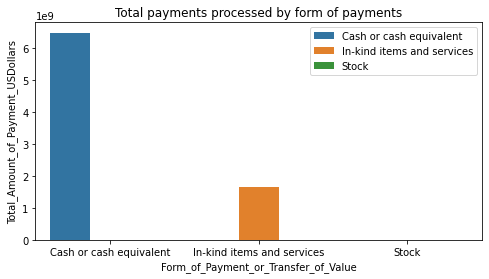

In [36]:
plt.title('Total payments processed by form of payments')
g=sns.barplot(data=fp_data, x='Form_of_Payment_or_Transfer_of_Value', y='Total_Amount_of_Payment_USDollars', hue='Form_of_Payment_or_Transfer_of_Value');
plt.legend( loc='upper right')
g.figure.set_size_inches(8, 4);


In [37]:
fp_data_avg=df_research.groupby('Form_of_Payment_or_Transfer_of_Value')['Total_Amount_of_Payment_USDollars'].mean().sort_values(ascending=False).reset_index()
fp_data_avg


,Form_of_Payment_or_Transfer_of_Value,Total_Amount_of_Payment_USDollars
0,Stock,12854.160000
1,In-kind items and services,10519.897822
2,Cash or cash equivalent,7425.385519


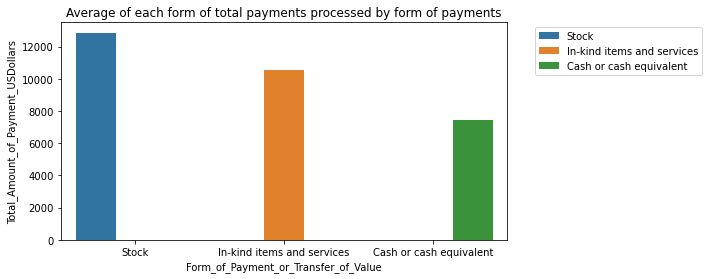

In [38]:
plt.title('Average of each form of total payments processed by form of payments')
g=sns.barplot(data=fp_data_avg, x='Form_of_Payment_or_Transfer_of_Value', y='Total_Amount_of_Payment_USDollars', hue='Form_of_Payment_or_Transfer_of_Value');
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
g.figure.set_size_inches(8, 4);

### Payments by recipients. Covered_Recipient_Type, Noncovered_Recipient_Entity_Name (associated with principal investigators) 

In [39]:
df_research.groupby('Covered_Recipient_Type')['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()


,Covered_Recipient_Type,Total_Amount_of_Payment_USDollars
0,Non-covered Recipient Entity,6.509944e+09
1,Covered Recipient Teaching Hospital,1.538407e+09
2,Covered Recipient Physician,7.132706e+07
3,Non-covered Recipient Individual,8.496183e+05
4,Covered Recipient Non-Physician Practitioner,5.315202e+05


In [40]:
6.509944e+09

6509944000.0

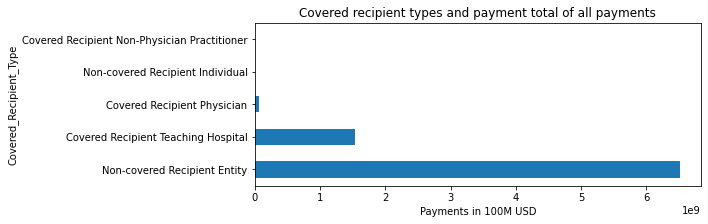

In [41]:
# Covered recipient types and total payments to each type
plt.figure(figsize=(8,3))
plt.title('Covered recipient types and payment total of all payments')
df_research.groupby(['Covered_Recipient_Type'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).plot(kind='barh');
plt.xlabel("Payments in 100M USD");

## Type 1: Non-covered Recipient Entity analysis

In [42]:
# Type 1: Non-covered Recipient Entity
df_research[df_research['Covered_Recipient_Type']=='Non-covered Recipient Entity'].describe().applymap('{:,.2f}'.format)


,Total_Amount_of_Payment_USDollars
count,"888,712.00"
mean,"7,325.14"
std,"68,001.78"
min,0.01
25%,68.20
50%,710.40
75%,"2,500.00"
max,"11,062,983.68"


In [43]:
df_research[df_research['Covered_Recipient_Type']=='Non-covered Recipient Entity'].describe(include=object)

,Covered_Recipient_Type,Noncovered_Recipient_Entity_Name,Teaching_Hospital_Name,Covered_Recipient_Profile_ID,Covered_Recipient_First_Name,Covered_Recipient_Last_Name,Recipient_State,Recipient_Country,Covered_Recipient_Primary_Type_1,Covered_Recipient_Specialty_1,...,Name_of_Study,ClinicalTrials_Gov_Identifier,Research_Information_Link,Context_of_Research,Covered_Recipient_gender,Principal_Investigator_5_gender,Principal_Investigator_4_gender,Principal_Investigator_3_gender,Principal_Investigator_2_gender,Principal_Investigator_1_gender
count,888712,888712,0,0,0,0,888401,888712,0,0,...,884632,449247,18389,90843,0,22,46,180,1674,888692
unique,1,23932,0,0,0,0,52,8,0,0,...,12015,1784,305,3182,0,2,2,2,2,2
top,Non-covered Recipient Entity,"clinedge, llc - ppds",NaN,NaN,NaN,NaN,FL,united states,NaN,NaN,...,"a phase 3, randomized, observer-blind, active-...",NCT05566639,https://clinicaltrials.gov/ct2/show/NCT0498720...,payments or transfers of value related to rese...,NaN,M,M,M,M,M
freq,888712,43688,NaN,NaN,NaN,NaN,159078,888401,NaN,NaN,...,130147,130147,1475,16392,NaN,18,40,150,1364,669629


**Non covered entities associated with Noncovered_Recipient_Entity_Name, Principal_Investigator_1_Profile_ID (2,3,4,5), Name_of_Study, ClinicalTrials_Gov_Identifier, Research_Information_Link, Context_of_Research**

In [44]:
NC_Entities=df_research[df_research['Covered_Recipient_Type']=='Non-covered Recipient Entity'].groupby('Noncovered_Recipient_Entity_Name')['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
NC_Entities


,Noncovered_Recipient_Entity_Name,Total_Amount_of_Payment_USDollars
0,national institute of health,1.440878e+08
1,memorial sloan kettering cancer center,8.744629e+07
2,"clinedge, llc - ppds",6.410748e+07
3,duke university,5.190447e+07
4,dynamed clinical research lp,4.494616e+07
...,...,...
23927,"hematology oncology associates, pc",1.000000e-02
23928,iu health goshen center for cancer care,1.000000e-02
23929,florida cancer affiliates - ocala,1.000000e-02
23930,st. luke's university hospital,1.000000e-02


In [45]:
NC_Entities.to_csv('NC_entities_research.csv')

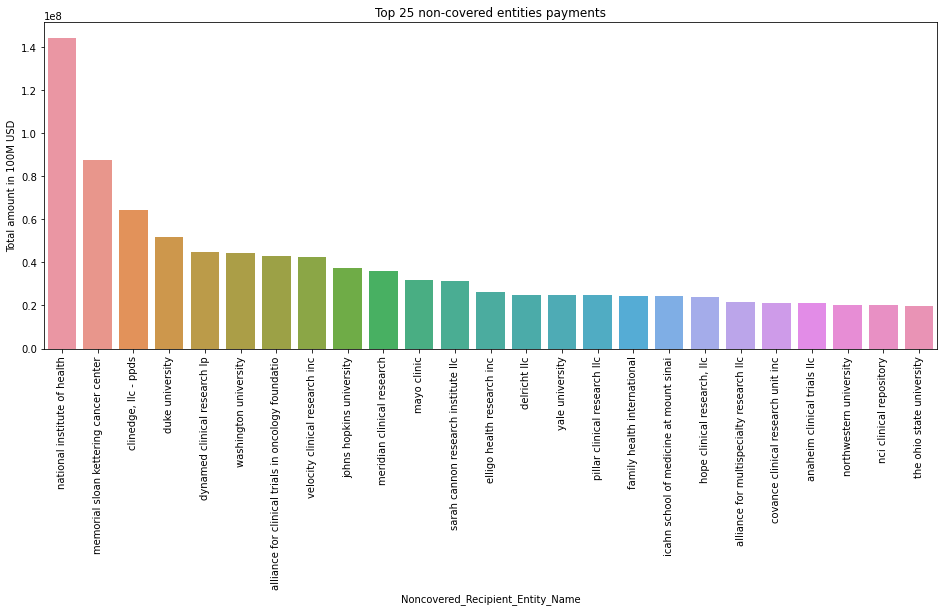

In [46]:
# Plot for total payment for top 25 entities
g=sns.barplot(data=NC_Entities[:25], x='Noncovered_Recipient_Entity_Name', y='Total_Amount_of_Payment_USDollars').set_title("Top 25 non-covered entities payments")
g.figure.set_size_inches(16, 6)
plt.ylabel("Total amount in 100M USD");
plt.xticks(rotation=90);


In [47]:
# Verifying features of all entities
df_research[df_research['Covered_Recipient_Type']=='Non-covered Recipient Entity']['Covered_Recipient_Profile_ID'].nunique()


0

In [48]:
# Verifying features of all entities
NC_Entities_investigators=df_research[df_research['Covered_Recipient_Type']=='Non-covered Recipient Entity'][['Noncovered_Recipient_Entity_Name',
                          'Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          'Principal_Investigator_4_Profile_ID','Principal_Investigator_5_Profile_ID',                                                                                                                                                                      
                          'Principal_Investigator_1_gender',  'Principal_Investigator_2_gender','Principal_Investigator_3_gender', 'Principal_Investigator_4_gender',  
                          'Principal_Investigator_5_gender', 'Name_of_Study', 'ClinicalTrials_Gov_Identifier',
                          'Research_Information_Link', 'Context_of_Research','Form_of_Payment_or_Transfer_of_Value', 'Total_Amount_of_Payment_USDollars']]



In [49]:
# stats
NC_Entities_investigators.describe(include=object)

,Noncovered_Recipient_Entity_Name,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID,Principal_Investigator_3_Profile_ID,Principal_Investigator_4_Profile_ID,Principal_Investigator_5_Profile_ID,Principal_Investigator_1_gender,Principal_Investigator_2_gender,Principal_Investigator_3_gender,Principal_Investigator_4_gender,Principal_Investigator_5_gender,Name_of_Study,ClinicalTrials_Gov_Identifier,Research_Information_Link,Context_of_Research,Form_of_Payment_or_Transfer_of_Value
count,888712,888625,1674,180,46,22,888692,1674,180,46,22,884632,449247,18389,90843,888712
unique,23932,24339,377,67,25,17,2,2,2,2,2,12015,1784,305,3182,2
top,"clinedge, llc - ppds",1679656656.0,24935.0,247322.0,11565533.0,207688.0,M,M,M,M,M,"a phase 3, randomized, observer-blind, active-...",NCT05566639,https://clinicaltrials.gov/ct2/show/NCT0498720...,payments or transfers of value related to rese...,Cash or cash equivalent
freq,43688,6852,363,31,11,6,669629,1364,150,40,18,130147,130147,1475,16392,764469


**Principal_investigators associated with entities**

In [50]:
# Verifying how many entities have all 5 investigators 

NC_5investigators=NC_Entities_investigators[['Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          'Principal_Investigator_4_Profile_ID','Principal_Investigator_5_Profile_ID']].dropna()

print("count of entities with 5 Principals associated\n", NC_5investigators.count())


count of entities with 5 Principals associated
 Principal_Investigator_1_Profile_ID    22
Principal_Investigator_2_Profile_ID    22
Principal_Investigator_3_Profile_ID    22
Principal_Investigator_4_Profile_ID    22
Principal_Investigator_5_Profile_ID    22
dtype: int64


In [51]:
# Verifying how many entities have 4 investigators 

NC_4investigators=NC_Entities_investigators[['Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          'Principal_Investigator_4_Profile_ID']].dropna()

print("count of entities with 4 Principals associated\n", NC_4investigators.count()- NC_5investigators.count())


count of entities with 4 Principals associated
 Principal_Investigator_1_Profile_ID    24.0
Principal_Investigator_2_Profile_ID    24.0
Principal_Investigator_3_Profile_ID    24.0
Principal_Investigator_4_Profile_ID    24.0
Principal_Investigator_5_Profile_ID     NaN
dtype: float64


In [52]:
# Verifying how many entities have 3 investigators 

NC_3investigators=NC_Entities_investigators[['Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          ]].dropna()

print("count of entities with 3 Principals associated\n", NC_3investigators.count()- NC_4investigators.count()- NC_5investigators.count())


count of entities with 3 Principals associated
 Principal_Investigator_1_Profile_ID    112.0
Principal_Investigator_2_Profile_ID    112.0
Principal_Investigator_3_Profile_ID    112.0
Principal_Investigator_4_Profile_ID      NaN
Principal_Investigator_5_Profile_ID      NaN
dtype: float64


In [53]:
# Verifying how many entities have 2 investigators 

NC_2investigators=NC_Entities_investigators[['Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' 
                          ]].dropna()

print("count of entities with 2 Principals associated\n", NC_2investigators.count()- NC_3investigators.count()- NC_4investigators.count()-NC_5investigators.count())


count of entities with 2 Principals associated
 Principal_Investigator_1_Profile_ID    1426.0
Principal_Investigator_2_Profile_ID    1426.0
Principal_Investigator_3_Profile_ID       NaN
Principal_Investigator_4_Profile_ID       NaN
Principal_Investigator_5_Profile_ID       NaN
dtype: float64


In [54]:
# Verifying how many entities have 1 investigator

NC_1investigators=NC_Entities_investigators[['Principal_Investigator_1_Profile_ID'
                          ]].dropna()

print("count of entities with 1 Principal associated\n", NC_1investigators.count()- NC_2investigators.count()- NC_3investigators.count()- NC_4investigators.count()-NC_5investigators.count())


count of entities with 1 Principal associated
 Principal_Investigator_1_Profile_ID    886703.0
Principal_Investigator_2_Profile_ID         NaN
Principal_Investigator_3_Profile_ID         NaN
Principal_Investigator_4_Profile_ID         NaN
Principal_Investigator_5_Profile_ID         NaN
dtype: float64


**22 Non covered recipient entities with 5 principal investigators, 24 with 4, 112 with 3, 1426 with 2, and 886703 with 1**

### Type 2: Teaching hospitals analysis and associations

In [55]:
df_research[df_research['Covered_Recipient_Type']=='Covered Recipient Teaching Hospital'].describe(include=object)

,Covered_Recipient_Type,Noncovered_Recipient_Entity_Name,Teaching_Hospital_Name,Covered_Recipient_Profile_ID,Covered_Recipient_First_Name,Covered_Recipient_Last_Name,Recipient_State,Recipient_Country,Covered_Recipient_Primary_Type_1,Covered_Recipient_Specialty_1,...,Name_of_Study,ClinicalTrials_Gov_Identifier,Research_Information_Link,Context_of_Research,Covered_Recipient_gender,Principal_Investigator_5_gender,Principal_Investigator_4_gender,Principal_Investigator_3_gender,Principal_Investigator_2_gender,Principal_Investigator_1_gender
count,113385,0,113385,0,0,0,113385,113385,0,0,...,112471,33987,5209,19674,0,20,47,70,496,108461
unique,1,0,666,0,0,0,51,1,0,0,...,7627,1213,222,1764,0,2,2,2,2,2
top,Covered Recipient Teaching Hospital,NaN,ut md anderson cancer center,NaN,NaN,NaN,CA,united states,NaN,NaN,...,nn9924-4437,NCT02152956,https://clinicaltrials.gov/ct2/show/NCT03975647,payments or transfers of value related to rese...,NaN,M,M,M,M,M
freq,113385,NaN,5217,NaN,NaN,NaN,15047,113385,NaN,NaN,...,2442,1442,458,4868,NaN,19,33,56,382,73239


In [56]:
# Verifying features of all teaching hospitals and people association
df_research[df_research['Covered_Recipient_Type']=='Covered Recipient Teaching Hospital']['Covered_Recipient_Profile_ID'].nunique()


0

In [57]:
# Verifying features of all teaching hospitals and people association
TH_investigators=df_research[df_research['Covered_Recipient_Type']=='Covered Recipient Teaching Hospital'][['Teaching_Hospital_Name',
                          'Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          'Principal_Investigator_4_Profile_ID','Principal_Investigator_5_Profile_ID',                                                                                                                                                                      
                          'Principal_Investigator_1_gender',  'Principal_Investigator_2_gender','Principal_Investigator_3_gender', 'Principal_Investigator_4_gender',  
                          'Principal_Investigator_5_gender', 'Name_of_Study', 'ClinicalTrials_Gov_Identifier',
                          'Research_Information_Link', 'Context_of_Research','Form_of_Payment_or_Transfer_of_Value','Total_Amount_of_Payment_USDollars']]
TH_investigators.describe(include=object)



,Teaching_Hospital_Name,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID,Principal_Investigator_3_Profile_ID,Principal_Investigator_4_Profile_ID,Principal_Investigator_5_Profile_ID,Principal_Investigator_1_gender,Principal_Investigator_2_gender,Principal_Investigator_3_gender,Principal_Investigator_4_gender,Principal_Investigator_5_gender,Name_of_Study,ClinicalTrials_Gov_Identifier,Research_Information_Link,Context_of_Research,Form_of_Payment_or_Transfer_of_Value
count,113385,108452,496,70,47,20,108461,496,70,47,20,112471,33987,5209,19674,113385
unique,666,9113,167,20,9,4,2,2,2,2,2,7627,1213,222,1764,3
top,ut md anderson cancer center,1942358411.0,11507.0,265293.0,6611.0,883425.0,M,M,M,M,M,nn9924-4437,NCT02152956,https://clinicaltrials.gov/ct2/show/NCT03975647,payments or transfers of value related to rese...,Cash or cash equivalent
freq,5217,1378,58,17,17,17,73239,382,56,33,19,2442,1442,458,4868,94773


In [58]:
TH_investigators.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113385 entries, 0 to 144264
Data columns (total 17 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Teaching_Hospital_Name                113385 non-null  object 
 1   Principal_Investigator_1_Profile_ID   108452 non-null  object 
 2   Principal_Investigator_2_Profile_ID   496 non-null     object 
 3   Principal_Investigator_3_Profile_ID   70 non-null      object 
 4   Principal_Investigator_4_Profile_ID   47 non-null      object 
 5   Principal_Investigator_5_Profile_ID   20 non-null      object 
 6   Principal_Investigator_1_gender       108461 non-null  object 
 7   Principal_Investigator_2_gender       496 non-null     object 
 8   Principal_Investigator_3_gender       70 non-null      object 
 9   Principal_Investigator_4_gender       47 non-null      object 
 10  Principal_Investigator_5_gender       20 non-null      object 
 11  Name_

In [59]:
Teaching_hospitals=df_research[df_research['Covered_Recipient_Type']=='Covered Recipient Teaching Hospital'].groupby('Teaching_Hospital_Name')['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
Teaching_hospitals


,Teaching_Hospital_Name,Total_Amount_of_Payment_USDollars
0,ut md anderson cancer center,2.668078e+08
1,dana-farber cancer institute,6.722050e+07
2,langley porter psychiatric hospital,6.187970e+07
3,hospital of the univ of penna,5.126738e+07
4,brigham and womens hospital,4.881446e+07
...,...,...
661,north mississippi medical center,1.038000e+02
662,owensboro health regional hospital,5.000000e+01
663,memorial hospital of rhode island,4.792000e+01
664,childrens medical center of dallas,3.187000e+01


In [59]:
Teaching_hospitals.to_csv('teaching_hospitals_research.csv')

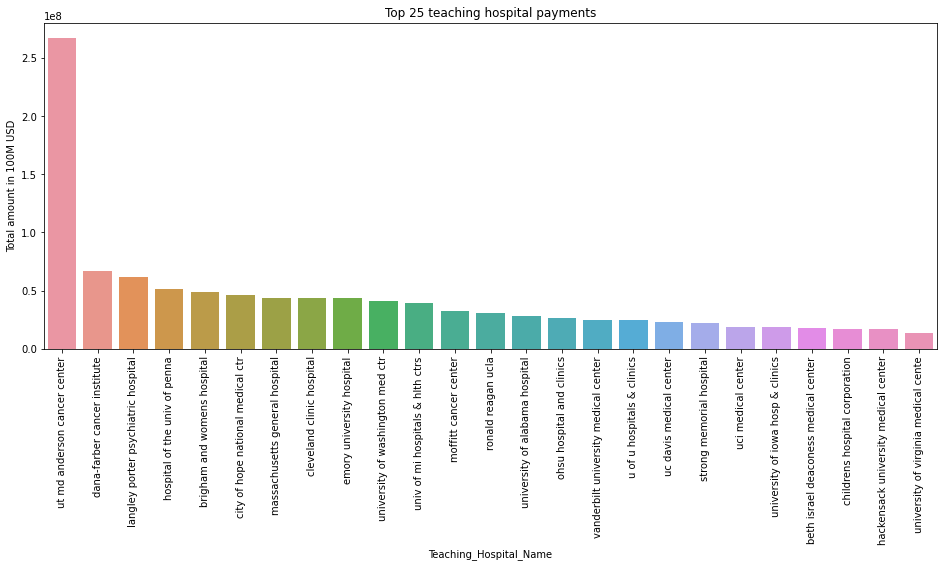

In [60]:
# Plot for total payment for top 25 entities
g=sns.barplot(data=Teaching_hospitals[:25], x='Teaching_Hospital_Name', y='Total_Amount_of_Payment_USDollars').set_title("Top 25 teaching hospital payments")
g.figure.set_size_inches(16, 6)
plt.ylabel("Total amount in 100M USD");
plt.xticks(rotation=90);



In [61]:
# Verifying how many TH have all 5 investigators 

TH_5investigators=TH_investigators[['Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          'Principal_Investigator_4_Profile_ID','Principal_Investigator_5_Profile_ID']].dropna()

print("count of entities with 5 Principals associated\n", TH_5investigators.count())


count of entities with 5 Principals associated
 Principal_Investigator_1_Profile_ID    20
Principal_Investigator_2_Profile_ID    20
Principal_Investigator_3_Profile_ID    20
Principal_Investigator_4_Profile_ID    20
Principal_Investigator_5_Profile_ID    20
dtype: int64


In [62]:
# Verifying how many TH have all 4 investigators 

TH_4investigators=TH_investigators[['Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          'Principal_Investigator_4_Profile_ID']].dropna()

print("count of entities with 4 Principals associated\n", TH_4investigators.count()-TH_5investigators.count())


count of entities with 4 Principals associated
 Principal_Investigator_1_Profile_ID    27.0
Principal_Investigator_2_Profile_ID    27.0
Principal_Investigator_3_Profile_ID    27.0
Principal_Investigator_4_Profile_ID    27.0
Principal_Investigator_5_Profile_ID     NaN
dtype: float64


In [63]:
# Verifying how many TH have all 3 investigators 

TH_3investigators=TH_investigators[['Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          ]].dropna()

print("count of entities with 3 Principals associated\n", TH_3investigators.count()-TH_4investigators.count()-TH_5investigators.count())


count of entities with 3 Principals associated
 Principal_Investigator_1_Profile_ID    3.0
Principal_Investigator_2_Profile_ID    3.0
Principal_Investigator_3_Profile_ID    3.0
Principal_Investigator_4_Profile_ID    NaN
Principal_Investigator_5_Profile_ID    NaN
dtype: float64


In [64]:
# Verifying how many TH have all 2 investigators 

TH_2investigators=TH_investigators[['Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID'
                          ]].dropna()

print("count of entities with 2 Principals associated\n", TH_2investigators.count()-TH_3investigators.count()-TH_4investigators.count()-TH_5investigators.count())


count of entities with 2 Principals associated
 Principal_Investigator_1_Profile_ID    359.0
Principal_Investigator_2_Profile_ID    359.0
Principal_Investigator_3_Profile_ID      NaN
Principal_Investigator_4_Profile_ID      NaN
Principal_Investigator_5_Profile_ID      NaN
dtype: float64


In [65]:
# Verifying how many TH have all 1 investigators 

TH_1investigators=TH_investigators[['Principal_Investigator_1_Profile_ID']].dropna()

print("count of entities with 1 Principals associated\n", TH_1investigators.count()-TH_2investigators.count()-TH_3investigators.count()-TH_4investigators.count()-TH_5investigators.count())


count of entities with 1 Principals associated
 Principal_Investigator_1_Profile_ID    107819.0
Principal_Investigator_2_Profile_ID         NaN
Principal_Investigator_3_Profile_ID         NaN
Principal_Investigator_4_Profile_ID         NaN
Principal_Investigator_5_Profile_ID         NaN
dtype: float64


**20 TH have 5 principal investigators, 27 TH have 4 principal investigators, 3 TH have 3 principal investigators, 359 TH have 2 principal investigators, 107819 TH have 1 principal investigators.**

In [66]:
# Verifying if same physician has different profiles as physician, investigator etc...
TH_5investigators

,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID,Principal_Investigator_3_Profile_ID,Principal_Investigator_4_Profile_ID,Principal_Investigator_5_Profile_ID
10599,1386619575.0,262262.0,265293.0,6611.0,883425.0
14461,1386619575.0,262262.0,265293.0,6611.0,883425.0
22632,1639100506.0,463312.0,1126016.0,482891.0,227297.0
23095,1386619575.0,262262.0,265293.0,6611.0,883425.0
26844,1386619575.0,262262.0,265293.0,6611.0,883425.0
28617,1386619575.0,262262.0,265293.0,6611.0,883425.0
31222,1386619575.0,262262.0,265293.0,6611.0,883425.0
38274,1386619575.0,262262.0,265293.0,6611.0,883425.0
43418,1386619575.0,262262.0,265293.0,6611.0,883425.0
44075,1386619575.0,262262.0,265293.0,6611.0,883425.0


In [67]:
## To verify if individuals are same or different with different profie IDs in a record

df_research.loc[141815][['Covered_Recipient_Profile_ID','Covered_Recipient_First_Name', 'Covered_Recipient_Last_Name',
                          'Principal_Investigator_1_Profile_ID', 'Principal_Investigator_1_First_Name', 'Principal_Investigator_1_Last_Name',
                          'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_2_First_Name', 'Principal_Investigator_2_Last_Name',
                        'Principal_Investigator_3_Profile_ID','Principal_Investigator_3_First_Name', 'Principal_Investigator_3_Last_Name',
                         'Principal_Investigator_4_Profile_ID','Principal_Investigator_4_First_Name', 'Principal_Investigator_4_Last_Name',
                        'Principal_Investigator_5_Profile_ID','Principal_Investigator_5_First_Name', 'Principal_Investigator_5_Last_Name']]


Covered_Recipient_Profile_ID                    NaN
Covered_Recipient_First_Name                    NaN
Covered_Recipient_Last_Name                     NaN
Principal_Investigator_1_Profile_ID    1386619575.0
Principal_Investigator_1_First_Name           james
Principal_Investigator_1_Last_Name      blankenship
Principal_Investigator_2_Profile_ID        262262.0
Principal_Investigator_2_First_Name            amir
Principal_Investigator_2_Last_Name            lotfi
Principal_Investigator_3_Profile_ID        265293.0
Principal_Investigator_3_First_Name         nainesh
Principal_Investigator_3_Last_Name            patel
Principal_Investigator_4_Profile_ID          6611.0
Principal_Investigator_4_First_Name             hal
Principal_Investigator_4_Last_Name        wasserman
Principal_Investigator_5_Profile_ID        883425.0
Principal_Investigator_5_First_Name         michael
Principal_Investigator_5_Last_Name           butler
Name: 141815, dtype: object

### Type 3: Covered Recipient Physician analysis and associations with investigators

**Individual recipient categories: Covered Recipient Physician, Non-covered Recipient Individual, Covered Recipient Non-Physician Practitioner**

In [68]:
# Verifying features of all physicians and the roles as investigators
physicians=df_research[df_research['Covered_Recipient_Type']=='Covered Recipient Physician'][['Covered_Recipient_Profile_ID',
                          'Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          'Principal_Investigator_4_Profile_ID','Principal_Investigator_5_Profile_ID',                                                                                                                                                                      
                          'Principal_Investigator_1_gender',  'Principal_Investigator_2_gender','Principal_Investigator_3_gender', 'Principal_Investigator_4_gender',  
                          'Principal_Investigator_5_gender', 'Name_of_Study', 'ClinicalTrials_Gov_Identifier',
                          'Research_Information_Link', 'Context_of_Research','Form_of_Payment_or_Transfer_of_Value','Total_Amount_of_Payment_USDollars']]

physicians.describe(include=object)


,Covered_Recipient_Profile_ID,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID,Principal_Investigator_3_Profile_ID,Principal_Investigator_4_Profile_ID,Principal_Investigator_5_Profile_ID,Principal_Investigator_1_gender,Principal_Investigator_2_gender,Principal_Investigator_3_gender,Principal_Investigator_4_gender,Principal_Investigator_5_gender,Name_of_Study,ClinicalTrials_Gov_Identifier,Research_Information_Link,Context_of_Research,Form_of_Payment_or_Transfer_of_Value
count,25137,102,2,1,1,1,103,2,1,1,1,24783,7024,2115,8722,25137
unique,5436,23,2,1,1,1,2,1,1,1,1,1857,453,120,170,2
top,303222.0,1679689145.0,6617290.0,265293.0,6611.0,883425.0,M,M,M,M,M,nautilus study,NCT05202808,https://clinicaltrials.gov/ct2/show/NCT0443751...,the amount reported represents either an aggre...,In-kind items and services
freq,295,21,1,1,1,1,88,2,1,1,1,617,230,199,1981,12715


In [69]:
physicians.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25137 entries, 21 to 144263
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Covered_Recipient_Profile_ID          25137 non-null  object 
 1   Principal_Investigator_1_Profile_ID   102 non-null    object 
 2   Principal_Investigator_2_Profile_ID   2 non-null      object 
 3   Principal_Investigator_3_Profile_ID   1 non-null      object 
 4   Principal_Investigator_4_Profile_ID   1 non-null      object 
 5   Principal_Investigator_5_Profile_ID   1 non-null      object 
 6   Principal_Investigator_1_gender       103 non-null    object 
 7   Principal_Investigator_2_gender       2 non-null      object 
 8   Principal_Investigator_3_gender       1 non-null      object 
 9   Principal_Investigator_4_gender       1 non-null      object 
 10  Principal_Investigator_5_gender       1 non-null      object 
 11  Name_of_Study     

In [70]:
# Checking if investigators also get paid in commom transactions in this category
physicians[['Covered_Recipient_Profile_ID',
        'Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ]].dropna()


,Covered_Recipient_Profile_ID,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID
2657,234935.0,1407895477.0,6617290.0
23508,50779.0,1386619575.0,262262.0


In [71]:
# Checking if investigators also get paid in commom transactions in this category
physicians[['Covered_Recipient_Profile_ID',
                          'Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          'Principal_Investigator_4_Profile_ID','Principal_Investigator_5_Profile_ID']].dropna()

,Covered_Recipient_Profile_ID,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID,Principal_Investigator_3_Profile_ID,Principal_Investigator_4_Profile_ID,Principal_Investigator_5_Profile_ID
23508,50779.0,1386619575.0,262262.0,265293.0,6611.0,883425.0


In [72]:
# OTHER record
df_research.loc[23508][['Covered_Recipient_Profile_ID','Covered_Recipient_First_Name', 'Covered_Recipient_Last_Name',
                          'Principal_Investigator_1_Profile_ID', 'Principal_Investigator_1_First_Name', 'Principal_Investigator_1_Last_Name',
                          'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_2_First_Name', 'Principal_Investigator_2_Last_Name',
                        'Principal_Investigator_3_Profile_ID','Principal_Investigator_3_First_Name', 'Principal_Investigator_3_Last_Name',
                         'Principal_Investigator_4_Profile_ID','Principal_Investigator_4_First_Name', 'Principal_Investigator_4_Last_Name',
                        'Principal_Investigator_5_Profile_ID','Principal_Investigator_5_First_Name', 'Principal_Investigator_5_Last_Name']]



Covered_Recipient_Profile_ID                50779.0
Covered_Recipient_First_Name                  gregg
Covered_Recipient_Last_Name                   stone
Principal_Investigator_1_Profile_ID    1386619575.0
Principal_Investigator_1_First_Name           james
Principal_Investigator_1_Last_Name      blankenship
Principal_Investigator_2_Profile_ID        262262.0
Principal_Investigator_2_First_Name            amir
Principal_Investigator_2_Last_Name            lotfi
Principal_Investigator_3_Profile_ID        265293.0
Principal_Investigator_3_First_Name         nainesh
Principal_Investigator_3_Last_Name            patel
Principal_Investigator_4_Profile_ID          6611.0
Principal_Investigator_4_First_Name             hal
Principal_Investigator_4_Last_Name        wasserman
Principal_Investigator_5_Profile_ID        883425.0
Principal_Investigator_5_First_Name         michael
Principal_Investigator_5_Last_Name           butler
Name: 23508, dtype: object

### Type 4: Non-covered Recipient Individual analysis and associations with investigator role

In [73]:
# Verifying features of all non_covered recipients and the roles as investigators
non_covered_recip_ind=df_research[df_research['Covered_Recipient_Type']=='Non-covered Recipient Individual'][['Covered_Recipient_Profile_ID',
                          'Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          'Principal_Investigator_4_Profile_ID','Principal_Investigator_5_Profile_ID',                                                                                                                                                                      
                          'Principal_Investigator_1_gender',  'Principal_Investigator_2_gender','Principal_Investigator_3_gender', 'Principal_Investigator_4_gender',  
                          'Principal_Investigator_5_gender', 'Name_of_Study', 'ClinicalTrials_Gov_Identifier',
                          'Research_Information_Link', 'Context_of_Research','Form_of_Payment_or_Transfer_of_Value','Total_Amount_of_Payment_USDollars']]
non_covered_recip_ind.describe(include=object)


,Covered_Recipient_Profile_ID,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID,Principal_Investigator_3_Profile_ID,Principal_Investigator_4_Profile_ID,Principal_Investigator_5_Profile_ID,Principal_Investigator_1_gender,Principal_Investigator_2_gender,Principal_Investigator_3_gender,Principal_Investigator_4_gender,Principal_Investigator_5_gender,Name_of_Study,ClinicalTrials_Gov_Identifier,Research_Information_Link,Context_of_Research,Form_of_Payment_or_Transfer_of_Value
count,0,70,0,0,0,0,70,0,0,0,0,70,33,0,18,70
unique,0,22,0,0,0,0,2,0,0,0,0,20,11,0,1,2
top,NaN,1942381579.0,NaN,NaN,NaN,NaN,M,NaN,NaN,NaN,NaN,"a multinational, multicenter, randomized, doub...",NCT05329129,NaN,patient outcomes,Cash or cash equivalent
freq,NaN,11,NaN,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,22,16,NaN,18,68


In [74]:
non_covered_recip_ind.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70 entries, 157254 to 1017386
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Covered_Recipient_Profile_ID          0 non-null      object 
 1   Principal_Investigator_1_Profile_ID   70 non-null     object 
 2   Principal_Investigator_2_Profile_ID   0 non-null      object 
 3   Principal_Investigator_3_Profile_ID   0 non-null      object 
 4   Principal_Investigator_4_Profile_ID   0 non-null      object 
 5   Principal_Investigator_5_Profile_ID   0 non-null      object 
 6   Principal_Investigator_1_gender       70 non-null     object 
 7   Principal_Investigator_2_gender       0 non-null      object 
 8   Principal_Investigator_3_gender       0 non-null      object 
 9   Principal_Investigator_4_gender       0 non-null      object 
 10  Principal_Investigator_5_gender       0 non-null      object 
 11  Name_of_Study   

**The non covered recipients are in Principal_Investigator_1_Profiles 70 transactions**

### Type 5: Covered Recipient Non-Physician Practitioner analysis and investigator associations

In [75]:
### # Verifying features of all Covered Recipient Non-Physician Practitioner and the roles as investigators 
covered_nonphys=df_research[df_research['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner'][['Covered_Recipient_Profile_ID',
                          'Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          'Principal_Investigator_4_Profile_ID','Principal_Investigator_5_Profile_ID',                                                                                                                                                                      
                          'Principal_Investigator_1_gender',  'Principal_Investigator_2_gender','Principal_Investigator_3_gender', 'Principal_Investigator_4_gender',  
                          'Principal_Investigator_5_gender', 'Name_of_Study', 'ClinicalTrials_Gov_Identifier',
                          'Research_Information_Link', 'Context_of_Research','Form_of_Payment_or_Transfer_of_Value','Total_Amount_of_Payment_USDollars']]
covered_nonphys.describe(include=object)



,Covered_Recipient_Profile_ID,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID,Principal_Investigator_3_Profile_ID,Principal_Investigator_4_Profile_ID,Principal_Investigator_5_Profile_ID,Principal_Investigator_1_gender,Principal_Investigator_2_gender,Principal_Investigator_3_gender,Principal_Investigator_4_gender,Principal_Investigator_5_gender,Name_of_Study,ClinicalTrials_Gov_Identifier,Research_Information_Link,Context_of_Research,Form_of_Payment_or_Transfer_of_Value
count,1168,13,0,0,0,0,13,0,0,0,0,1162,329,12,238,1168
unique,226,2,0,0,0,0,2,0,0,0,0,112,26,8,16,2
top,10787297.0,1154426955.0,NaN,NaN,NaN,NaN,F,NaN,NaN,NaN,NaN,lvans,NCT06130566,https://clinicaltrials.gov/study/NCT05467072?i...,m23-696,In-kind items and services
freq,19,12,NaN,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,102,85,4,46,915


In [76]:
covered_nonphys.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 2 to 143608
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Covered_Recipient_Profile_ID          1168 non-null   object 
 1   Principal_Investigator_1_Profile_ID   13 non-null     object 
 2   Principal_Investigator_2_Profile_ID   0 non-null      object 
 3   Principal_Investigator_3_Profile_ID   0 non-null      object 
 4   Principal_Investigator_4_Profile_ID   0 non-null      object 
 5   Principal_Investigator_5_Profile_ID   0 non-null      object 
 6   Principal_Investigator_1_gender       13 non-null     object 
 7   Principal_Investigator_2_gender       0 non-null      object 
 8   Principal_Investigator_3_gender       0 non-null      object 
 9   Principal_Investigator_4_gender       0 non-null      object 
 10  Principal_Investigator_5_gender       0 non-null      object 
 11  Name_of_Study       

# Feature engineering

# Column of number of people paid

In [77]:
df_research = df_research.assign(Payee_num = lambda x: x['Covered_Recipient_Profile_ID'].notna().astype(int)+
                                            x['Principal_Investigator_1_Profile_ID'].notna().astype(int) +
                                            x['Principal_Investigator_2_Profile_ID'].notna().astype(int)+
                                             x['Principal_Investigator_3_Profile_ID'].notna().astype(int)+
                                             x['Principal_Investigator_4_Profile_ID'].notna().astype(int)+
                                             x['Principal_Investigator_5_Profile_ID'].notna().astype(int))
                                                        

In [78]:
df_research['Payee_num'].describe().astype(int)

count    1028472
mean           0
std            0
min            0
25%            1
50%            1
75%            1
max            6
Name: Payee_num, dtype: int64

In [79]:
# Checking out records with 0 profile ID associated.
df_research[df_research['Payee_num']==0].index

Index([     41,     115,     120,     157,     207,     238,     324,     332,
           338,     373,
       ...
        925660,  928001,  936539,  953760,  961418,  979565,  981585,  991097,
       1003313, 1015996],
      dtype='int64', length=5020)

In [80]:
df_research.loc[df_research[df_research['Payee_num']==0].index][['Covered_Recipient_Profile_ID',
                          'Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          'Principal_Investigator_4_Profile_ID','Principal_Investigator_5_Profile_ID'                                                                                                                                                                     
                          ]].describe()

,Covered_Recipient_Profile_ID,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID,Principal_Investigator_3_Profile_ID,Principal_Investigator_4_Profile_ID,Principal_Investigator_5_Profile_ID
count,0,0,0,0,0,0
unique,0,0,0,0,0,0
top,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN


In [81]:
# Payment stats related to records with no individuals associated.
df_research.loc[df_research[df_research['Payee_num']==0].index]['Total_Amount_of_Payment_USDollars'].describe()


count    5.020000e+03
mean     4.108443e+04
std      2.029279e+05
min      1.400000e-01
25%      8.572550e+02
50%      4.957860e+03
75%      2.568799e+04
max      8.333335e+06
Name: Total_Amount_of_Payment_USDollars, dtype: float64

In [82]:
df_research.loc[df_research[df_research['Payee_num']==0].index][['Covered_Recipient_Type', 'Noncovered_Recipient_Entity_Name','Teaching_Hospital_Name']].describe()


,Covered_Recipient_Type,Noncovered_Recipient_Entity_Name,Teaching_Hospital_Name
count,5020,87,4933
unique,2,30,250
top,Covered Recipient Teaching Hospital,orlando health pediatric neurology,university of iowa hosp & clinics
freq,4933,25,415


In [83]:
df_research.loc[df_research[df_research['Payee_num']==0].index].Covered_Recipient_Type.value_counts(dropna=False)


Covered_Recipient_Type
Covered Recipient Teaching Hospital    4933
Non-covered Recipient Entity             87
Name: count, dtype: int64

### 5020 payments to teaching hospitals and non-covered recipient entities. No individual profiles associated. 

In [84]:
## Verifying the records we saw earlier.
df_research.loc[43418]['Payee_num']

5

In [85]:
df_research.loc[2657]['Payee_num']

3

In [86]:
# Distributed total payment engineered
df_research['Dist_total_Payment_in_USD']=df_research['Total_Amount_of_Payment_USDollars']/df_research['Payee_num']


In [87]:
df_research[['Dist_total_Payment_in_USD','Total_Amount_of_Payment_USDollars']].describe().applymap('{:,.2f}'.format)


,Dist_total_Payment_in_USD,Total_Amount_of_Payment_USDollars
count,"1,028,472.00","1,028,472.00"
mean,inf,"7,896.24"
std,nan,"70,670.15"
min,0.01,0.01
25%,76.05,76.02
50%,742.44,742.44
75%,"2,695.96","2,675.33"
max,inf,"13,607,486.88"


### The inf payments are related to those with no profile IDs associated. Will not impact analysis for individuals.

In [88]:
## Saving file with engineered features. 
df_research.to_csv('Master_Research_data_cleaned_gender_payee_num_dist_payment_added_12Nov.csv')


# 5 types of recipients and gender and gender based payment analysis.

### NC_Entities_investigators, TH_investigators, physicians, non_covered_recip_ind, covered_nonphys

# NON COVERED RECIPIENT ENTITIES

In [89]:
# Verifying features of all entities, adding payee_num column and Dist_total_Payment_in_USD
NC_Entities_investigators=df_research[df_research['Covered_Recipient_Type']=='Non-covered Recipient Entity'][['Noncovered_Recipient_Entity_Name',
                          'Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          'Principal_Investigator_4_Profile_ID','Principal_Investigator_5_Profile_ID', 'Payee_num',                                                                                                                                                                     
                          'Principal_Investigator_1_gender',  'Principal_Investigator_2_gender','Principal_Investigator_3_gender', 'Principal_Investigator_4_gender',  
                          'Principal_Investigator_5_gender', 'Name_of_Study', 'ClinicalTrials_Gov_Identifier',
                          'Research_Information_Link', 'Context_of_Research','Form_of_Payment_or_Transfer_of_Value','Dist_total_Payment_in_USD','Total_Amount_of_Payment_USDollars']]

NC_Entities_investigators=NC_Entities_investigators.sort_values(by='Total_Amount_of_Payment_USDollars', ascending=False)


In [90]:
NC_Entities_investigators.describe()

,Payee_num,Dist_total_Payment_in_USD,Total_Amount_of_Payment_USDollars
count,888712.000000,888712.00,8.887120e+05
mean,1.002065,inf,7.325144e+03
std,0.054927,NaN,6.800178e+04
min,0.000000,0.01,1.000000e-02
25%,1.000000,68.20,6.820000e+01
50%,1.000000,708.50,7.104000e+02
75%,1.000000,2500.00,2.500000e+03
max,5.000000,inf,1.106298e+07


In [91]:
NC_Entities_investigators.describe(include=object)

,Noncovered_Recipient_Entity_Name,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID,Principal_Investigator_3_Profile_ID,Principal_Investigator_4_Profile_ID,Principal_Investigator_5_Profile_ID,Principal_Investigator_1_gender,Principal_Investigator_2_gender,Principal_Investigator_3_gender,Principal_Investigator_4_gender,Principal_Investigator_5_gender,Name_of_Study,ClinicalTrials_Gov_Identifier,Research_Information_Link,Context_of_Research,Form_of_Payment_or_Transfer_of_Value
count,888712,888625,1674,180,46,22,888692,1674,180,46,22,884632,449247,18389,90843,888712
unique,23932,24339,377,67,25,17,2,2,2,2,2,12015,1784,305,3182,2
top,"clinedge, llc - ppds",1679656656.0,24935.0,247322.0,11565533.0,207688.0,M,M,M,M,M,"a phase 3, randomized, observer-blind, active-...",NCT05566639,https://clinicaltrials.gov/ct2/show/NCT0498720...,payments or transfers of value related to rese...,Cash or cash equivalent
freq,43688,6852,363,31,11,6,669629,1364,150,40,18,130147,130147,1475,16392,764469


In [92]:
NC_Entities_investigators[:40][['Payee_num','Dist_total_Payment_in_USD','Total_Amount_of_Payment_USDollars']]

,Payee_num,Dist_total_Payment_in_USD,Total_Amount_of_Payment_USDollars
734554,1,11062983.68,11062983.68
157303,1,10592241.89,10592241.89
499229,1,9874411.92,9874411.92
701499,1,9797500.00,9797500.00
384500,1,8475408.00,8475408.00
262643,1,8386026.00,8386026.00
155028,1,7875000.00,7875000.00
505385,1,7551020.88,7551020.88
397982,1,7286809.99,7286809.99
833011,1,7200000.00,7200000.00


## Top 40 payments are to single investigaters

**For individual profile the 'Dist_total_Payment_in_USD' will be used, for company level 'Total_Amount_of_Payment_USDollars'**

**Due to multiple people involved in few payments. the amount is equally divided. This will be approximated values, as distribution is not known.**

In [93]:
## Creating the dataframe of all investigators their genders and distributed payments. 

In [94]:
NC_Entities_investigators_1=NC_Entities_investigators[['Principal_Investigator_1_Profile_ID','Principal_Investigator_1_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]


NC_Entities_investigators_1=NC_Entities_investigators_1.rename(columns={'Principal_Investigator_1_Profile_ID':'Principal_Investigator_Profile_ID',
                                           'Principal_Investigator_1_gender': 'Principal_Investigator_gender'
                                           })
NC_Entities_investigators_1.describe(include=object)


,Principal_Investigator_Profile_ID,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value
count,888625,888692,888712
unique,24339,2,2
top,1679656656.0,M,Cash or cash equivalent
freq,6852,669629,764469


In [95]:
NC_Entities_investigators_2=NC_Entities_investigators[['Principal_Investigator_2_Profile_ID','Principal_Investigator_2_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]

NC_Entities_investigators_2=NC_Entities_investigators_2.rename(columns={'Principal_Investigator_2_Profile_ID':'Principal_Investigator_Profile_ID',
                                           'Principal_Investigator_2_gender': 'Principal_Investigator_gender'
                                           })
NC_Entities_investigators_2.describe(include=object)



,Principal_Investigator_Profile_ID,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value
count,1674,1674,888712
unique,377,2,2
top,24935.0,M,Cash or cash equivalent
freq,363,1364,764469


In [96]:
NC_Entities_investigators_3=NC_Entities_investigators[['Principal_Investigator_3_Profile_ID','Principal_Investigator_3_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]

NC_Entities_investigators_3=NC_Entities_investigators_3.rename(columns={'Principal_Investigator_3_Profile_ID':'Principal_Investigator_Profile_ID',
                                           'Principal_Investigator_3_gender': 'Principal_Investigator_gender'
                                           })
NC_Entities_investigators_3.describe(include=object)



,Principal_Investigator_Profile_ID,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value
count,180,180,888712
unique,67,2,2
top,247322.0,M,Cash or cash equivalent
freq,31,150,764469


In [97]:
NC_Entities_investigators_4=NC_Entities_investigators[['Principal_Investigator_4_Profile_ID','Principal_Investigator_4_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]

NC_Entities_investigators_4=NC_Entities_investigators_4.rename(columns={'Principal_Investigator_4_Profile_ID':'Principal_Investigator_Profile_ID',
                                           'Principal_Investigator_4_gender': 'Principal_Investigator_gender'
                                           })
NC_Entities_investigators_4.describe(include=object)


,Principal_Investigator_Profile_ID,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value
count,46,46,888712
unique,25,2,2
top,11565533.0,M,Cash or cash equivalent
freq,11,40,764469


In [98]:
NC_Entities_investigators_5=NC_Entities_investigators[['Principal_Investigator_5_Profile_ID','Principal_Investigator_5_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]

NC_Entities_investigators_5=NC_Entities_investigators_5.rename(columns={'Principal_Investigator_5_Profile_ID':'Principal_Investigator_Profile_ID',
                                           'Principal_Investigator_5_gender': 'Principal_Investigator_gender'
                                           })
NC_Entities_investigators_5.describe(include=object)

,Principal_Investigator_Profile_ID,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value
count,22,22,888712
unique,17,2,2
top,207688.0,M,Cash or cash equivalent
freq,6,18,764469


In [99]:
NC_investigator_all=pd.concat([NC_Entities_investigators_1, NC_Entities_investigators_2,
           NC_Entities_investigators_3, NC_Entities_investigators_4,
           NC_Entities_investigators_5])
NC_investigator_all         



,Principal_Investigator_Profile_ID,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
734554,1528060357.0,M,Cash or cash equivalent,11062983.68
157303,1821289794.0,M,In-kind items and services,10592241.89
499229,1992712178.0,F,In-kind items and services,9874411.92
701499,1437126018.0,F,In-kind items and services,9797500.00
384500,1649428053.0,F,In-kind items and services,8475408.00
...,...,...,...,...
739046,NaN,NaN,In-kind items and services,0.01
262153,NaN,NaN,In-kind items and services,0.01
922351,NaN,NaN,In-kind items and services,0.01
170253,NaN,NaN,In-kind items and services,0.01


In [100]:
# Total should be thrice of 888712.
4443560/5

888712.0

**Removing all nan profiles**

In [101]:
NC_investigator_all=NC_investigator_all[NC_investigator_all['Principal_Investigator_Profile_ID'].notna()]

In [102]:
## Grouping all individual transactions
NC_investigator_ind=NC_investigator_all.groupby(['Principal_Investigator_Profile_ID','Principal_Investigator_gender'])['Dist_total_Payment_in_USD'].sum().sort_values(ascending=False).reset_index()
NC_investigator_ind


,Principal_Investigator_Profile_ID,Principal_Investigator_gender,Dist_total_Payment_in_USD
0,1295712677.0,M,75847728.66
1,1851515035.0,F,68912077.65
2,1437126018.0,F,56144277.26
3,1144299173.0,M,27799973.04
4,1861538647.0,F,24400000.00
...,...,...,...
24820,1952364994.0,M,4.20
24821,1245313972.0,M,2.35
24822,1891767174.0,M,1.53
24823,1265498976.0,M,1.00


In [103]:
NC_invest_gender=NC_investigator_ind.groupby('Principal_Investigator_gender')['Principal_Investigator_Profile_ID'].nunique().reset_index()
NC_invest_gender


,Principal_Investigator_gender,Principal_Investigator_Profile_ID
0,F,6792
1,M,18033


In [104]:
# Function to create charts by profile
my_palette ={"F": "C1", "M": "C0"}
def create_chart_gender(df, col1, col2, col3, description, y_axis):
    my_palette ={"F":'orange', "M": 'blue'}
    plt.title(description)
    g=sns.barplot(data=df, x=col1, y=col2, hue=col3, palette=my_palette);
    # Place the legend outside the plot
    plt.ylabel(y_axis)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    g.figure.set_size_inches(7, 4);
    


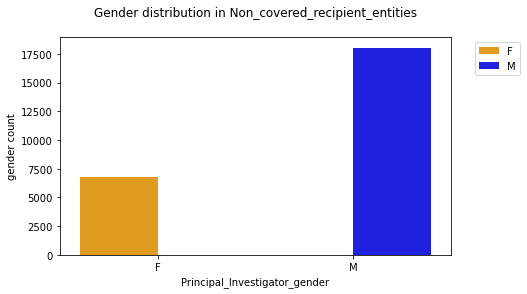

In [105]:
create_chart_gender(NC_invest_gender, 'Principal_Investigator_gender', 'Principal_Investigator_Profile_ID', 'Principal_Investigator_gender', 
                    'Gender distribution in Non_covered_recipient_entities\n', 'gender count')



In [106]:
# Total by gender based payments
NC_gender_pay=NC_investigator_all.groupby(['Principal_Investigator_gender'])['Dist_total_Payment_in_USD'].sum().reset_index()

NC_gender_pay



,Principal_Investigator_gender,Dist_total_Payment_in_USD
0,F,1.859018e+09
1,M,4.646859e+09


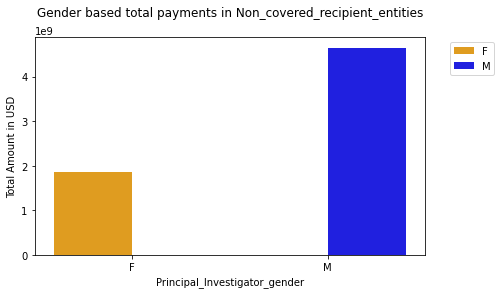

In [107]:
create_chart_gender(NC_gender_pay, 'Principal_Investigator_gender', 'Dist_total_Payment_in_USD', 'Principal_Investigator_gender', 
                    'Gender based total payments in Non_covered_recipient_entities\n', 'Total Amount in USD')


In [108]:
# Total by gender based payments
NC_gender_pay_form=NC_investigator_all.groupby(['Principal_Investigator_gender','Form_of_Payment_or_Transfer_of_Value'])['Dist_total_Payment_in_USD'].sum().reset_index()

NC_gender_pay_form



,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
0,F,Cash or cash equivalent,1.397075e+09
1,F,In-kind items and services,4.619427e+08
2,M,Cash or cash equivalent,3.911095e+09
3,M,In-kind items and services,7.357637e+08


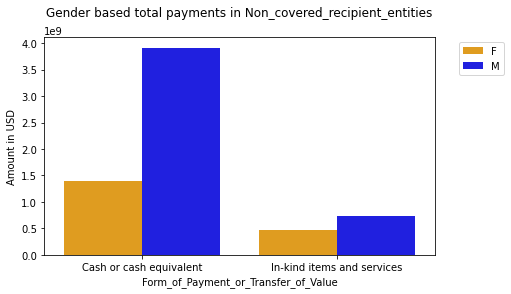

In [109]:
# Form of payments and amount by gender

create_chart_gender(NC_gender_pay_form,'Form_of_Payment_or_Transfer_of_Value','Dist_total_Payment_in_USD', 'Principal_Investigator_gender',
                    'Gender based total payments in Non_covered_recipient_entities\n', 'Amount in USD')


In [110]:
# Total by gender & individuals based payments
NC_individuals=NC_investigator_all.groupby(['Principal_Investigator_gender','Principal_Investigator_Profile_ID'])['Dist_total_Payment_in_USD'].sum().sort_values(ascending=False).reset_index()

NC_individuals


,Principal_Investigator_gender,Principal_Investigator_Profile_ID,Dist_total_Payment_in_USD
0,M,1295712677.0,75847728.66
1,F,1851515035.0,68912077.65
2,F,1437126018.0,56144277.26
3,M,1144299173.0,27799973.04
4,F,1861538647.0,24400000.00
...,...,...,...
24820,M,1952364994.0,4.20
24821,M,1245313972.0,2.35
24822,M,1891767174.0,1.53
24823,M,1265498976.0,1.00


In [111]:
NC_individuals[:50].groupby('Principal_Investigator_gender').describe()

Dist_total_Payment_in_USD                \
                                                  count          mean   
Principal_Investigator_gender                                           
F                                                  15.0  2.070807e+07   
M                                                  35.0  1.483496e+07   

                                                                        \
                                        std          min           25%   
Principal_Investigator_gender                                            
F                              1.755164e+07  10100237.15  1.102643e+07   
M                              1.117997e+07   9694173.57  1.097090e+07   

                                                                       
                                       50%           75%          max  
Principal_Investigator_gender                                          
F                              13998486.11  1.732341e+07  68912077.65  
M                              11785734.86  1.437666e+07  75847728.66

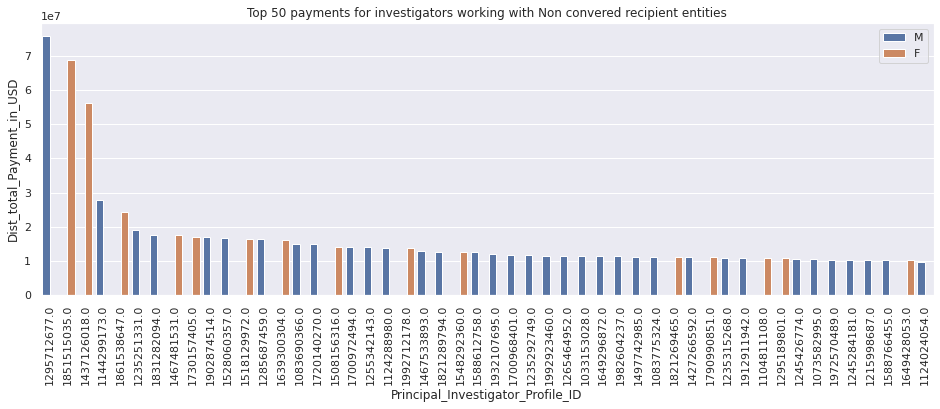

In [112]:
sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=NC_individuals[:50], x='Principal_Investigator_Profile_ID', y='Dist_total_Payment_in_USD', hue='Principal_Investigator_gender', 
              order=NC_individuals[:50].sort_values('Dist_total_Payment_in_USD', ascending=False).Principal_Investigator_Profile_ID, palette=my_palette)
g.set(title='Top 50 payments for investigators working with Non convered recipient entities')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');



In [113]:
# Total by individuals & gender based payments
NC_individuals_form=NC_investigator_all.groupby(['Principal_Investigator_gender','Principal_Investigator_Profile_ID','Form_of_Payment_or_Transfer_of_Value'])['Dist_total_Payment_in_USD'].sum().sort_values(ascending=False).reset_index()

NC_individuals_form

,Principal_Investigator_gender,Principal_Investigator_Profile_ID,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
0,M,1295712677.0,In-kind items and services,75321908.80
1,F,1851515035.0,In-kind items and services,65957618.05
2,F,1437126018.0,In-kind items and services,40750145.89
3,M,1144299173.0,Cash or cash equivalent,27675582.56
4,F,1861538647.0,Cash or cash equivalent,24400000.00
...,...,...,...,...
32196,F,1205803202.0,In-kind items and services,0.05
32197,M,1568406288.0,In-kind items and services,0.03
32198,F,1477745800.0,In-kind items and services,0.01
32199,M,1841274164.0,In-kind items and services,0.01


In [114]:
# Individual top 25 payee by form in-kind-items-and-services
NC_individuals_form[NC_individuals_form['Form_of_Payment_or_Transfer_of_Value']=='In-kind items and services'][:50].describe(include=object)



,Principal_Investigator_gender,Principal_Investigator_Profile_ID,Form_of_Payment_or_Transfer_of_Value
count,50,50,50
unique,2,50,1
top,M,1295712677.0,In-kind items and services
freq,28,1,50


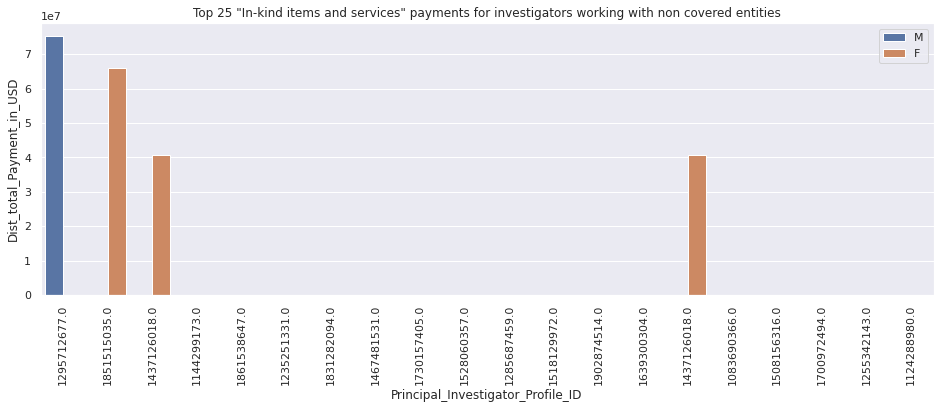

In [115]:
sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=NC_individuals_form[NC_individuals_form['Form_of_Payment_or_Transfer_of_Value']=='In-kind items and services'][:20], x='Principal_Investigator_Profile_ID', y='Dist_total_Payment_in_USD', hue='Principal_Investigator_gender', 
              order=NC_individuals_form[:20].sort_values('Dist_total_Payment_in_USD', ascending=False).Principal_Investigator_Profile_ID, palette=my_palette)
g.set(title='Top 25 "In-kind items and services" payments for investigators working with non covered entities')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');


In [116]:
## Top 25 individuals in 'cash or cash equivalent payments'
NC_individuals_form[NC_individuals_form['Form_of_Payment_or_Transfer_of_Value']=='Cash or cash equivalent'][:50].describe(include=object)


,Principal_Investigator_gender,Principal_Investigator_Profile_ID,Form_of_Payment_or_Transfer_of_Value
count,50,50,50
unique,2,50,1
top,M,1144299173.0,Cash or cash equivalent
freq,36,1,50


In [117]:
NC_individuals_form[NC_individuals_form['Form_of_Payment_or_Transfer_of_Value']=='Cash or cash equivalent'][:50]


,Principal_Investigator_gender,Principal_Investigator_Profile_ID,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
3,M,1144299173.0,Cash or cash equivalent,2.767558e+07
4,F,1861538647.0,Cash or cash equivalent,2.440000e+07
5,M,1235251331.0,Cash or cash equivalent,1.907165e+07
6,M,1831282094.0,Cash or cash equivalent,1.769284e+07
7,F,1467481531.0,Cash or cash equivalent,1.757700e+07
8,F,1730157405.0,Cash or cash equivalent,1.683036e+07
9,M,1528060357.0,Cash or cash equivalent,1.671337e+07
10,M,1285687459.0,Cash or cash equivalent,1.630811e+07
11,F,1518129972.0,Cash or cash equivalent,1.615467e+07
12,M,1902874514.0,Cash or cash equivalent,1.595226e+07


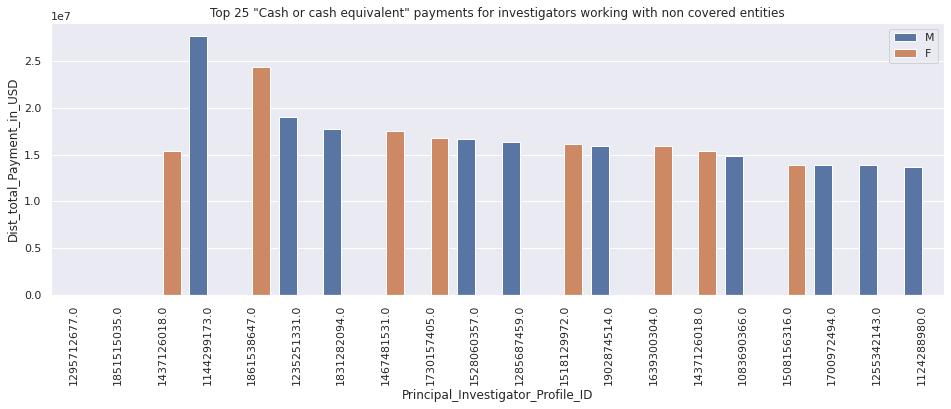

In [118]:

sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=NC_individuals_form[NC_individuals_form['Form_of_Payment_or_Transfer_of_Value']=='Cash or cash equivalent'][:20], x='Principal_Investigator_Profile_ID', y='Dist_total_Payment_in_USD', hue='Principal_Investigator_gender', 
              order=NC_individuals_form[:20].sort_values('Dist_total_Payment_in_USD', ascending=False).Principal_Investigator_Profile_ID, palette=my_palette)
g.set(title='Top 25 "Cash or cash equivalent" payments for investigators working with non covered entities')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');



### In top 50: total payments 15 are females. For cash or cash equivalent there are 14 females and in-kind-items and services 22 females.

In [119]:
# Average by gender based payments
NC_gender_pay_mean=NC_investigator_all.groupby(['Principal_Investigator_gender'])['Dist_total_Payment_in_USD'].mean().reset_index()

NC_gender_pay_mean

,Principal_Investigator_gender,Dist_total_Payment_in_USD
0,F,8473.266026
1,M,6923.943046


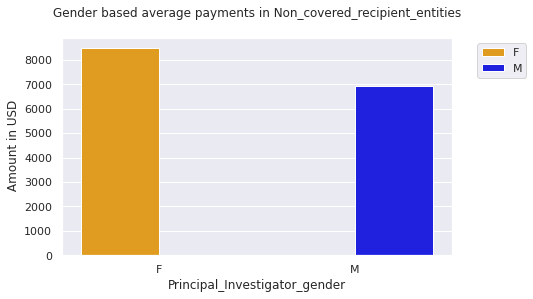

In [120]:
create_chart_gender(NC_gender_pay_mean, 'Principal_Investigator_gender', 'Dist_total_Payment_in_USD', 'Principal_Investigator_gender', 
                    'Gender based average payments in Non_covered_recipient_entities\n',' Amount in USD')


In [121]:
# Average by gender based payments
NC_gender_pay_median=NC_investigator_all.groupby(['Principal_Investigator_gender'])['Dist_total_Payment_in_USD'].median().reset_index()

NC_gender_pay_median

,Principal_Investigator_gender,Dist_total_Payment_in_USD
0,F,800.00
1,M,688.31


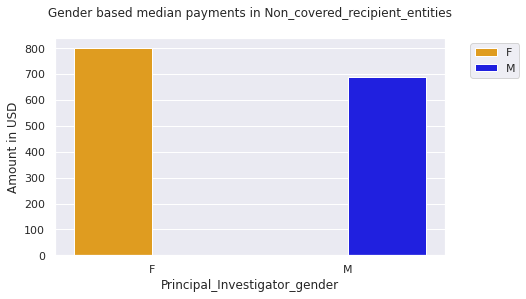

In [122]:
create_chart_gender(NC_gender_pay_median, 'Principal_Investigator_gender', 'Dist_total_Payment_in_USD', 'Principal_Investigator_gender', 
                    'Gender based median payments in Non_covered_recipient_entities\n','Amount in USD')


In [123]:
# Average by gender based payments forms
NC_gender_pay_form_average=NC_investigator_all.groupby(['Principal_Investigator_gender','Form_of_Payment_or_Transfer_of_Value'])['Dist_total_Payment_in_USD'].mean().reset_index()

NC_gender_pay_form_average


,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
0,F,Cash or cash equivalent,7423.273370
1,F,In-kind items and services,14807.754998
2,M,Cash or cash equivalent,6766.881710
3,M,In-kind items and services,7898.443955


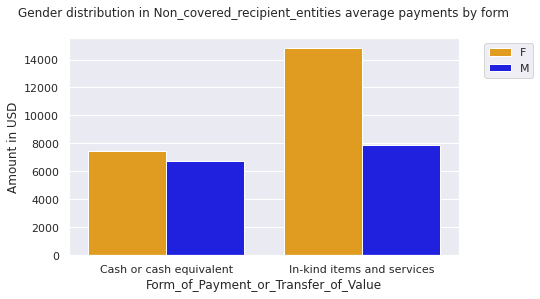

In [124]:
# Average Form of payments and amount by gender

create_chart_gender(NC_gender_pay_form_average,'Form_of_Payment_or_Transfer_of_Value','Dist_total_Payment_in_USD', 'Principal_Investigator_gender',
                    'Gender distribution in Non_covered_recipient_entities average payments by form\n', 'Amount in USD')


In [125]:
# Average by gender based payments forms
NC_gender_pay_form_median=NC_investigator_all.groupby(['Principal_Investigator_gender','Form_of_Payment_or_Transfer_of_Value'])['Dist_total_Payment_in_USD'].median().reset_index()

NC_gender_pay_form_median

,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
0,F,Cash or cash equivalent,965.0
1,F,In-kind items and services,30.0
2,M,Cash or cash equivalent,829.0
3,M,In-kind items and services,30.0


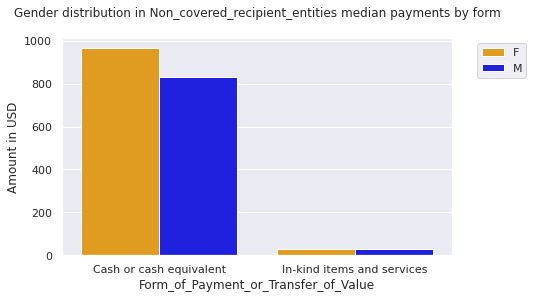

In [126]:
# Average Form of payments and amount by gender

create_chart_gender(NC_gender_pay_form_median,'Form_of_Payment_or_Transfer_of_Value','Dist_total_Payment_in_USD', 'Principal_Investigator_gender',
                    'Gender distribution in Non_covered_recipient_entities median payments by form\n',  'Amount in USD')

# Teaching hospital payments

In [127]:
df_research['Covered_Recipient_Type'].value_counts()

Covered_Recipient_Type
Non-covered Recipient Entity                    888712
Covered Recipient Teaching Hospital             113385
Covered Recipient Physician                      25137
Covered Recipient Non-Physician Practitioner      1168
Non-covered Recipient Individual                    70
Name: count, dtype: int64

In [128]:
# Verifying features of all entities
Teaching_hospitals_investigators=df_research[df_research['Covered_Recipient_Type']=='Covered Recipient Teaching Hospital'][['Teaching_Hospital_Name',
                          'Covered_Recipient_Profile_ID','Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          'Principal_Investigator_4_Profile_ID','Principal_Investigator_5_Profile_ID', 'Payee_num',                                                                                                                                                                     
                          'Principal_Investigator_1_gender',  'Principal_Investigator_2_gender','Principal_Investigator_3_gender', 'Principal_Investigator_4_gender',  
                          'Principal_Investigator_5_gender', 'Name_of_Study', 'ClinicalTrials_Gov_Identifier',
                          'Research_Information_Link', 'Context_of_Research','Form_of_Payment_or_Transfer_of_Value','Dist_total_Payment_in_USD','Total_Amount_of_Payment_USDollars']]



In [129]:
# Sortin for better view of top payments
Teaching_hospitals_investigators=Teaching_hospitals_investigators.sort_values(by='Total_Amount_of_Payment_USDollars', ascending=False)

Teaching_hospitals_investigators.describe()


,Payee_num,Dist_total_Payment_in_USD,Total_Amount_of_Payment_USDollars
count,113385.000000,113385.00,1.133850e+05
mean,0.962076,inf,1.356799e+04
std,0.227162,NaN,9.476590e+04
min,0.000000,0.01,1.000000e-02
25%,1.000000,290.25,2.680000e+02
50%,1.000000,1539.00,1.500000e+03
75%,1.000000,7122.00,5.976270e+03
max,5.000000,inf,1.360749e+07


In [130]:
# Categorical variables
Teaching_hospitals_investigators.describe(include=object)


,Teaching_Hospital_Name,Covered_Recipient_Profile_ID,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID,Principal_Investigator_3_Profile_ID,Principal_Investigator_4_Profile_ID,Principal_Investigator_5_Profile_ID,Principal_Investigator_1_gender,Principal_Investigator_2_gender,Principal_Investigator_3_gender,Principal_Investigator_4_gender,Principal_Investigator_5_gender,Name_of_Study,ClinicalTrials_Gov_Identifier,Research_Information_Link,Context_of_Research,Form_of_Payment_or_Transfer_of_Value
count,113385,0,108452,496,70,47,20,108461,496,70,47,20,112471,33987,5209,19674,113385
unique,666,0,9113,167,20,9,4,2,2,2,2,2,7627,1213,222,1764,3
top,ut md anderson cancer center,NaN,1942358411.0,11507.0,265293.0,6611.0,883425.0,M,M,M,M,M,nn9924-4437,NCT02152956,https://clinicaltrials.gov/ct2/show/NCT03975647,payments or transfers of value related to rese...,Cash or cash equivalent
freq,5217,NaN,1378,58,17,17,17,73239,382,56,33,19,2442,1442,458,4868,94773


In [131]:
Teaching_hospitals_investigators[:40][['Payee_num','Dist_total_Payment_in_USD','Total_Amount_of_Payment_USDollars']]


,Payee_num,Dist_total_Payment_in_USD,Total_Amount_of_Payment_USDollars
60583,1,1.360749e+07,13607486.88
79826,0,inf,8333335.34
39560,1,7.161835e+06,7161835.20
111239,0,inf,6000000.00
67742,1,5.371376e+06,5371376.40
82683,1,4.647240e+06,4647240.00
129129,0,inf,4244811.14
135163,1,4.032287e+06,4032287.26
6506,1,4.025200e+06,4025200.00
116310,1,4.025200e+06,4025200.00


In [132]:
### Records with no individual payee have inf. 
# We do not need for our analysis. Can be discared, however top level analysis is desirable.

In [133]:
## Creating the dataframe of all investigators their genders and distributed payments.No covered recipients


In [134]:
Teaching_hospitals_investigators_1=Teaching_hospitals_investigators[['Principal_Investigator_1_Profile_ID','Principal_Investigator_1_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]


Teaching_hospitals_investigators_1=Teaching_hospitals_investigators_1.rename(columns={'Principal_Investigator_1_Profile_ID':'Principal_Investigator_Profile_ID',
                                           'Principal_Investigator_1_gender': 'Principal_Investigator_gender'
                                           })
Teaching_hospitals_investigators_1.describe(include=object)


,Principal_Investigator_Profile_ID,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value
count,108452,108461,113385
unique,9113,2,3
top,1942358411.0,M,Cash or cash equivalent
freq,1378,73239,94773


In [135]:
Teaching_hospitals_investigators_2=Teaching_hospitals_investigators[['Principal_Investigator_2_Profile_ID','Principal_Investigator_2_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]

Teaching_hospitals_investigators_2=Teaching_hospitals_investigators_2.rename(columns={'Principal_Investigator_2_Profile_ID':'Principal_Investigator_Profile_ID',
                                           'Principal_Investigator_2_gender': 'Principal_Investigator_gender'
                                           })
Teaching_hospitals_investigators_2.describe(include=object)


,Principal_Investigator_Profile_ID,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value
count,496,496,113385
unique,167,2,3
top,11507.0,M,Cash or cash equivalent
freq,58,382,94773


In [136]:
Teaching_hospitals_investigators_3=Teaching_hospitals_investigators[['Principal_Investigator_3_Profile_ID','Principal_Investigator_3_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]

Teaching_hospitals_investigators_3=Teaching_hospitals_investigators_3.rename(columns={'Principal_Investigator_3_Profile_ID':'Principal_Investigator_Profile_ID',
                                           'Principal_Investigator_3_gender': 'Principal_Investigator_gender'
                                           })
Teaching_hospitals_investigators_3.describe(include=object)


,Principal_Investigator_Profile_ID,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value
count,70,70,113385
unique,20,2,3
top,265293.0,M,Cash or cash equivalent
freq,17,56,94773


In [137]:

Teaching_hospitals_investigators_4=Teaching_hospitals_investigators[['Principal_Investigator_4_Profile_ID','Principal_Investigator_4_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]

Teaching_hospitals_investigators_4=Teaching_hospitals_investigators_4.rename(columns={'Principal_Investigator_4_Profile_ID':'Principal_Investigator_Profile_ID',
                                           'Principal_Investigator_4_gender': 'Principal_Investigator_gender'
                                           })
Teaching_hospitals_investigators_4.describe(include=object)


,Principal_Investigator_Profile_ID,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value
count,47,47,113385
unique,9,2,3
top,6611.0,M,Cash or cash equivalent
freq,17,33,94773


In [138]:
Teaching_hospitals_investigators_5=Teaching_hospitals_investigators[['Principal_Investigator_5_Profile_ID','Principal_Investigator_5_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]

Teaching_hospitals_investigators_5=Teaching_hospitals_investigators_5.rename(columns={'Principal_Investigator_5_Profile_ID':'Principal_Investigator_Profile_ID',
                                           'Principal_Investigator_5_gender': 'Principal_Investigator_gender'
                                           })
Teaching_hospitals_investigators_5.describe(include=object)


,Principal_Investigator_Profile_ID,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value
count,20,20,113385
unique,4,2,3
top,883425.0,M,Cash or cash equivalent
freq,17,19,94773


## Combining all investigators in on dataframe

In [139]:
# Concating
Teaching_hospitals_investigators_all=pd.concat([Teaching_hospitals_investigators_1, Teaching_hospitals_investigators_2,
           Teaching_hospitals_investigators_3, Teaching_hospitals_investigators_4,
           Teaching_hospitals_investigators_5])
Teaching_hospitals_investigators_all    


,Principal_Investigator_Profile_ID,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
60583,1497848279.0,M,In-kind items and services,13607486.88
79826,NaN,NaN,Cash or cash equivalent,inf
39560,1407946460.0,M,In-kind items and services,7161835.20
111239,NaN,NaN,Cash or cash equivalent,inf
67742,1972615102.0,M,In-kind items and services,5371376.40
...,...,...,...,...
136180,NaN,NaN,Cash or cash equivalent,0.01
20853,NaN,NaN,Cash or cash equivalent,0.01
129394,NaN,NaN,Cash or cash equivalent,0.01
94361,NaN,NaN,In-kind items and services,0.01


In [140]:
113385*5

## Total records match

566925

In [141]:
# Dropping records with no profiles associated
Teaching_hospitals_investigators_all=Teaching_hospitals_investigators_all[Teaching_hospitals_investigators_all['Principal_Investigator_Profile_ID'].notna()]

Teaching_hospitals_investigators_all.describe(include=object)  


,Principal_Investigator_Profile_ID,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value
count,109085,109084,109085
unique,9311,2,2
top,1942358411.0,M,Cash or cash equivalent
freq,1378,73719,91095


In [142]:
# gender count
## Grouping all individual transactions

Teaching_hospitals_invest= Teaching_hospitals_investigators_all.groupby(['Principal_Investigator_Profile_ID','Principal_Investigator_gender'])['Dist_total_Payment_in_USD'].sum().sort_values(ascending=False).reset_index()
Teaching_hospitals_invest


,Principal_Investigator_Profile_ID,Principal_Investigator_gender,Dist_total_Payment_in_USD
0,1215108303.0,M,34196147.07
1,1316000771.0,F,19029630.43
2,1497848279.0,M,15354484.94
3,1437189768.0,M,9008239.33
4,1942743216.0,M,8016218.41
...,...,...,...
9311,1497965412.0,M,3.58
9312,1346264553.0,M,2.94
9313,1336191345.0,M,1.96
9314,1407182579.0,F,1.38


In [143]:
Teaching_hospital_gender=Teaching_hospitals_invest.groupby('Principal_Investigator_gender')['Principal_Investigator_Profile_ID'].nunique().reset_index()
Teaching_hospital_gender


,Principal_Investigator_gender,Principal_Investigator_Profile_ID
0,F,2833
1,M,6483


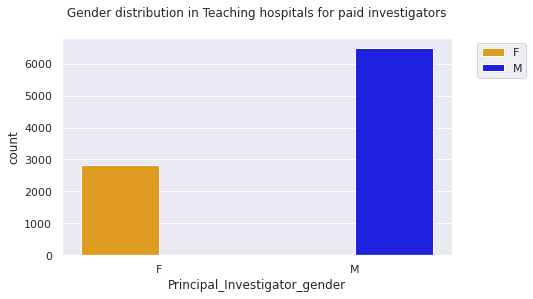

In [144]:
create_chart_gender(Teaching_hospital_gender, 'Principal_Investigator_gender', 'Principal_Investigator_Profile_ID', 'Principal_Investigator_gender', 
                    'Gender distribution in Teaching hospitals for paid investigators\n', 'count')


In [145]:
# Total by gender based payments
Teaching_hospitals_gender_pay=Teaching_hospitals_invest.groupby(['Principal_Investigator_gender'])['Dist_total_Payment_in_USD'].sum().reset_index()

Teaching_hospitals_gender_pay


,Principal_Investigator_gender,Dist_total_Payment_in_USD
0,F,3.879436e+08
1,M,9.479648e+08


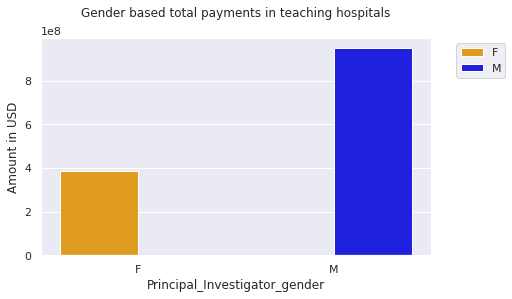

In [146]:
create_chart_gender(Teaching_hospitals_gender_pay, 'Principal_Investigator_gender', 'Dist_total_Payment_in_USD', 'Principal_Investigator_gender', 
                    'Gender based total payments in teaching hospitals\n','Amount in USD')


In [147]:
# Total by gender based payments
TH_gender_pay_form=Teaching_hospitals_investigators_all.groupby(['Principal_Investigator_gender','Form_of_Payment_or_Transfer_of_Value'])['Dist_total_Payment_in_USD'].sum().reset_index()

TH_gender_pay_form

,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
0,F,Cash or cash equivalent,2.672812e+08
1,F,In-kind items and services,1.206623e+08
2,M,Cash or cash equivalent,6.373573e+08
3,M,In-kind items and services,3.106075e+08


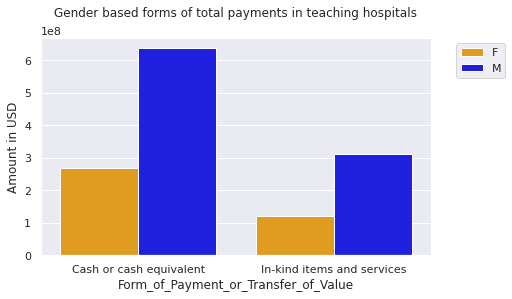

In [148]:
create_chart_gender(TH_gender_pay_form, 'Form_of_Payment_or_Transfer_of_Value','Dist_total_Payment_in_USD', 'Principal_Investigator_gender', 
                    'Gender based forms of total payments in teaching hospitals\n', 'Amount in USD')


In [149]:
# Total by individuals & gender based payments
TH_individuals=Teaching_hospitals_investigators_all.groupby(['Principal_Investigator_gender','Principal_Investigator_Profile_ID'])['Dist_total_Payment_in_USD'].sum().sort_values(ascending=False).reset_index()

TH_individuals

,Principal_Investigator_gender,Principal_Investigator_Profile_ID,Dist_total_Payment_in_USD
0,M,1215108303.0,34196147.07
1,F,1316000771.0,19029630.43
2,M,1497848279.0,15354484.94
3,M,1437189768.0,9008239.33
4,M,1942743216.0,8016218.41
...,...,...,...
9311,M,1497965412.0,3.58
9312,M,1346264553.0,2.94
9313,M,1336191345.0,1.96
9314,F,1407182579.0,1.38


In [150]:
TH_individuals[:50].describe(include=object)

,Principal_Investigator_gender,Principal_Investigator_Profile_ID
count,50,50
unique,2,50
top,M,1215108303.0
freq,36,1


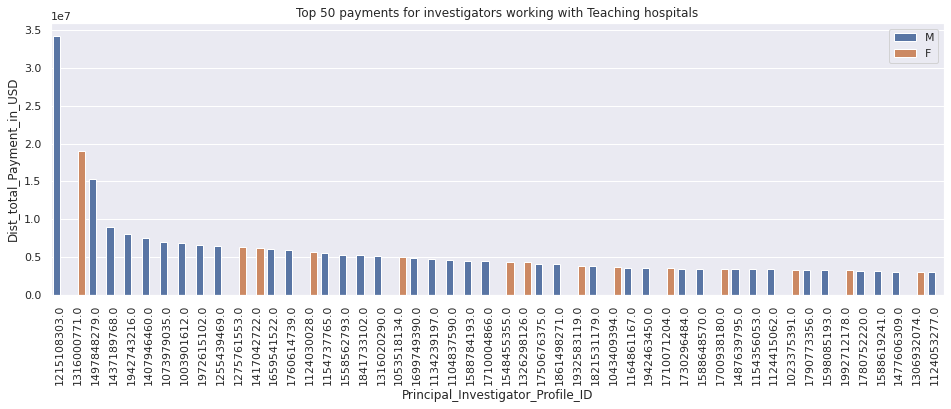

In [151]:
sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=TH_individuals[:50], x='Principal_Investigator_Profile_ID', y='Dist_total_Payment_in_USD', hue='Principal_Investigator_gender', 
              order=TH_individuals[:50].sort_values('Dist_total_Payment_in_USD', ascending=False).Principal_Investigator_Profile_ID, palette=my_palette)
g.set(title='Top 50 payments for investigators working with Teaching hospitals')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');


14 females in top 50 research investigators in teaching hospitals. 

In [152]:
# Total by individuals & gender based payments
TH_individuals_form=Teaching_hospitals_investigators_all.groupby(['Principal_Investigator_gender','Principal_Investigator_Profile_ID','Form_of_Payment_or_Transfer_of_Value'])['Dist_total_Payment_in_USD'].sum().sort_values(ascending=False).reset_index()

TH_individuals_form


,Principal_Investigator_gender,Principal_Investigator_Profile_ID,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
0,M,1215108303.0,In-kind items and services,33463603.21
1,F,1316000771.0,In-kind items and services,17992178.08
2,M,1497848279.0,In-kind items and services,13612713.42
3,M,1437189768.0,In-kind items and services,8576668.80
4,M,1407946460.0,In-kind items and services,7162588.79
...,...,...,...,...
11029,F,1457322166.0,In-kind items and services,0.01
11030,M,1134224595.0,In-kind items and services,0.01
11031,M,1427285451.0,In-kind items and services,0.01
11032,F,1568572592.0,In-kind items and services,0.01


In [153]:
TH_individuals_form[TH_individuals_form['Form_of_Payment_or_Transfer_of_Value']=='In-kind items and services'][:50]. describe(include=object)

,Principal_Investigator_gender,Principal_Investigator_Profile_ID,Form_of_Payment_or_Transfer_of_Value
count,50,50,50
unique,2,50,1
top,M,1215108303.0,In-kind items and services
freq,38,1,50


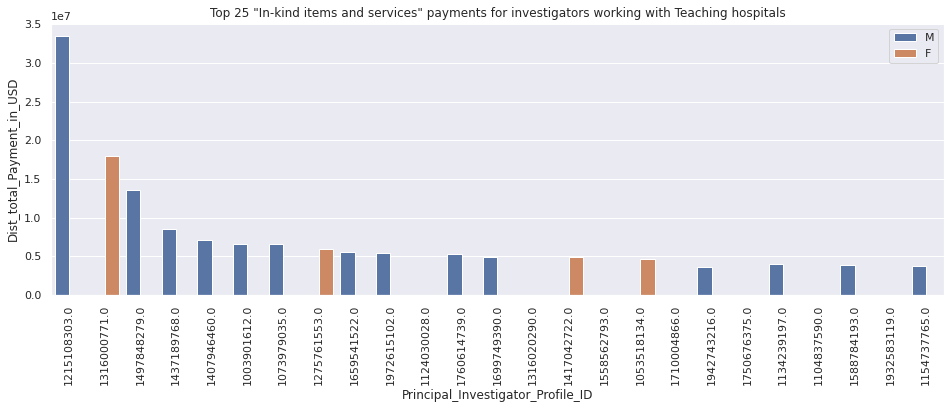

In [154]:
sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=TH_individuals_form[TH_individuals_form['Form_of_Payment_or_Transfer_of_Value']=='In-kind items and services'][:25], x='Principal_Investigator_Profile_ID', y='Dist_total_Payment_in_USD', hue='Principal_Investigator_gender', 
              order=TH_individuals_form[:25].sort_values('Dist_total_Payment_in_USD', ascending=False).Principal_Investigator_Profile_ID, palette=my_palette)
g.set(title='Top 25 "In-kind items and services" payments for investigators working with Teaching hospitals')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');


In [155]:
TH_individuals_form[TH_individuals_form['Form_of_Payment_or_Transfer_of_Value']=='Cash or cash equivalent'][:50].describe(include=object
                                                                                                                         )

,Principal_Investigator_gender,Principal_Investigator_Profile_ID,Form_of_Payment_or_Transfer_of_Value
count,50,50,50
unique,2,50,1
top,M,1124030028.0,Cash or cash equivalent
freq,38,1,50


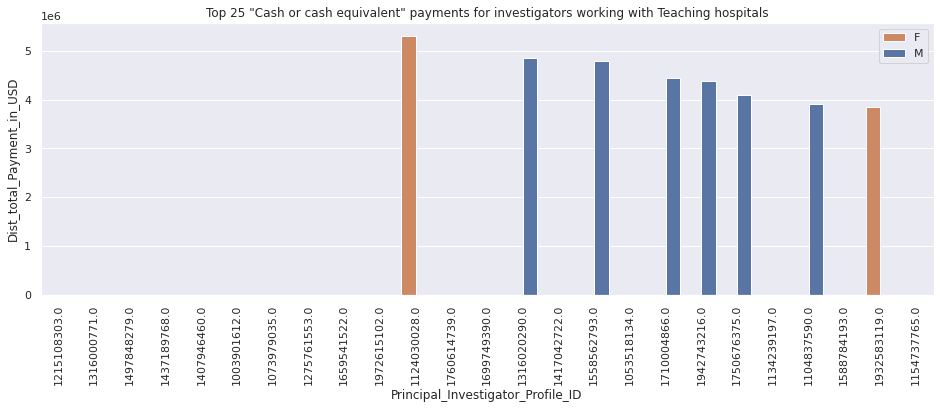

In [156]:
sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=TH_individuals_form[TH_individuals_form['Form_of_Payment_or_Transfer_of_Value']=='Cash or cash equivalent'][:25], x='Principal_Investigator_Profile_ID', y='Dist_total_Payment_in_USD', hue='Principal_Investigator_gender', 
              order=TH_individuals_form[:25].sort_values('Dist_total_Payment_in_USD', ascending=False).Principal_Investigator_Profile_ID, palette=my_palette)
g.set(title='Top 25 "Cash or cash equivalent" payments for investigators working with Teaching hospitals')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');


In [157]:

# Average by gender based payments
TH_gender_pay_mean=Teaching_hospitals_investigators_all.groupby(['Principal_Investigator_gender'])['Dist_total_Payment_in_USD'].mean().reset_index()

TH_gender_pay_mean


,Principal_Investigator_gender,Dist_total_Payment_in_USD
0,F,10969.703274
1,M,12859.165649


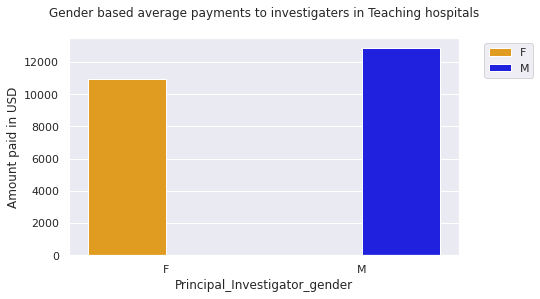

In [158]:
create_chart_gender(TH_gender_pay_mean, 'Principal_Investigator_gender', 'Dist_total_Payment_in_USD', 'Principal_Investigator_gender', 
                    'Gender based average payments to investigaters in Teaching hospitals\n', 'Amount paid in USD')


In [159]:

# Median by gender based payments
TH_gender_pay_median=Teaching_hospitals_investigators_all.groupby(['Principal_Investigator_gender'])['Dist_total_Payment_in_USD'].median().reset_index()
TH_gender_pay_median



,Principal_Investigator_gender,Dist_total_Payment_in_USD
0,F,1365.0
1,M,1419.3


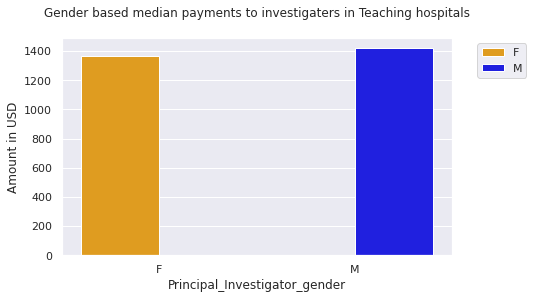

In [160]:
create_chart_gender(TH_gender_pay_median, 'Principal_Investigator_gender', 'Dist_total_Payment_in_USD', 'Principal_Investigator_gender', 
                    'Gender based median payments to investigaters in Teaching hospitals\n', 'Amount in USD')




In [161]:
# Median form of payments by gender 
TH_gender_pay_median_form=Teaching_hospitals_investigators_all.groupby(['Principal_Investigator_gender','Form_of_Payment_or_Transfer_of_Value' ])['Dist_total_Payment_in_USD'].median().reset_index()
TH_gender_pay_median_form



,Principal_Investigator_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
0,F,Cash or cash equivalent,1860.00
1,F,In-kind items and services,41.20
2,M,Cash or cash equivalent,1600.00
3,M,In-kind items and services,93.56


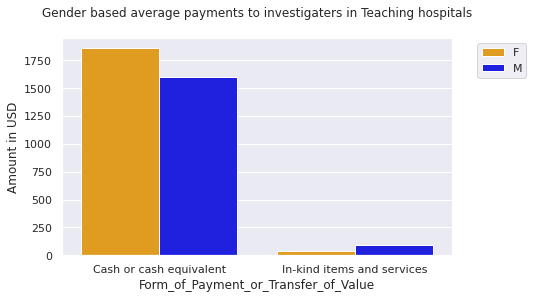

In [162]:
create_chart_gender(TH_gender_pay_median_form, 'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD', 'Principal_Investigator_gender', 
                    'Gender based average payments to investigaters in Teaching hospitals\n', 'Amount in USD')

### Covered Recipient Physician category 

In [163]:
# Verifying features of all entities
CR_physicians=df_research[df_research['Covered_Recipient_Type']=='Covered Recipient Physician'][[ 'Covered_Recipient_Profile_ID', 
                          'Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          'Principal_Investigator_4_Profile_ID','Principal_Investigator_5_Profile_ID', 'Payee_num', 'Covered_Recipient_gender',                                                                                                                                                                    
                          'Principal_Investigator_1_gender',  'Principal_Investigator_2_gender','Principal_Investigator_3_gender', 'Principal_Investigator_4_gender',  
                          'Principal_Investigator_5_gender', 'Name_of_Study', 'ClinicalTrials_Gov_Identifier',
                          'Research_Information_Link', 'Context_of_Research','Form_of_Payment_or_Transfer_of_Value','Dist_total_Payment_in_USD','Total_Amount_of_Payment_USDollars']]



In [164]:
CR_physicians.describe()

,Payee_num,Dist_total_Payment_in_USD,Total_Amount_of_Payment_USDollars
count,25137.000000,25137.000000,25137.000000
mean,1.004257,2819.429954,2837.532527
std,0.071512,12429.965033,12459.255433
min,1.000000,0.400000,0.400000
25%,1.000000,161.760000,161.760000
50%,1.000000,500.000000,500.000000
75%,1.000000,1516.600000,1525.020000
max,6.000000,521252.790000,521252.790000


In [165]:
CR_physicians.describe(include=object)

,Covered_Recipient_Profile_ID,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID,Principal_Investigator_3_Profile_ID,Principal_Investigator_4_Profile_ID,Principal_Investigator_5_Profile_ID,Covered_Recipient_gender,Principal_Investigator_1_gender,Principal_Investigator_2_gender,Principal_Investigator_3_gender,Principal_Investigator_4_gender,Principal_Investigator_5_gender,Name_of_Study,ClinicalTrials_Gov_Identifier,Research_Information_Link,Context_of_Research,Form_of_Payment_or_Transfer_of_Value
count,25137,102,2,1,1,1,25137,103,2,1,1,1,24783,7024,2115,8722,25137
unique,5436,23,2,1,1,1,2,2,1,1,1,1,1857,453,120,170,2
top,303222.0,1679689145.0,6617290.0,265293.0,6611.0,883425.0,M,M,M,M,M,M,nautilus study,NCT05202808,https://clinicaltrials.gov/ct2/show/NCT0443751...,the amount reported represents either an aggre...,In-kind items and services
freq,295,21,1,1,1,1,18004,88,2,1,1,1,617,230,199,1981,12715


**There are few combined payments to physicians and investigators**

In [166]:
CR_physicians[CR_physicians['Payee_num']== 6][['Covered_Recipient_Profile_ID','Principal_Investigator_1_Profile_ID','Principal_Investigator_2_Profile_ID',
                                             'Principal_Investigator_3_Profile_ID','Principal_Investigator_4_Profile_ID',
                                             'Principal_Investigator_5_Profile_ID','Payee_num','Form_of_Payment_or_Transfer_of_Value',
                                             'Dist_total_Payment_in_USD','Total_Amount_of_Payment_USDollars'
                                            ]]

,Covered_Recipient_Profile_ID,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID,Principal_Investigator_3_Profile_ID,Principal_Investigator_4_Profile_ID,Principal_Investigator_5_Profile_ID,Payee_num,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD,Total_Amount_of_Payment_USDollars
23508,50779.0,1386619575.0,262262.0,265293.0,6611.0,883425.0,6,Cash or cash equivalent,2500.0,15000.0


In [167]:
CR_physicians[CR_physicians['Payee_num']==5|4|3][['Covered_Recipient_Profile_ID','Principal_Investigator_1_Profile_ID','Principal_Investigator_2_Profile_ID',
                                             'Principal_Investigator_3_Profile_ID','Principal_Investigator_4_Profile_ID',
                                             'Principal_Investigator_5_Profile_ID','Payee_num','Form_of_Payment_or_Transfer_of_Value',
                                             'Dist_total_Payment_in_USD','Total_Amount_of_Payment_USDollars'
                                            ]]

,Covered_Recipient_Profile_ID,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID,Principal_Investigator_3_Profile_ID,Principal_Investigator_4_Profile_ID,Principal_Investigator_5_Profile_ID,Payee_num,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD,Total_Amount_of_Payment_USDollars


In [168]:
CR_physicians[CR_physicians['Payee_num']==2][['Covered_Recipient_Profile_ID','Principal_Investigator_1_Profile_ID','Principal_Investigator_2_Profile_ID',
                                             'Principal_Investigator_3_Profile_ID','Principal_Investigator_4_Profile_ID',
                                             'Principal_Investigator_5_Profile_ID','Payee_num','Form_of_Payment_or_Transfer_of_Value',
                                             'Dist_total_Payment_in_USD','Total_Amount_of_Payment_USDollars'
                                            ]]

,Covered_Recipient_Profile_ID,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID,Principal_Investigator_3_Profile_ID,Principal_Investigator_4_Profile_ID,Principal_Investigator_5_Profile_ID,Payee_num,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD,Total_Amount_of_Payment_USDollars
214,2775990.0,1679689145.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,350.0,700.0
423,28589.0,1447202163.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,175.0,350.0
481,63190.0,1205093895.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,1425.0,2850.0
1165,2775990.0,1679689145.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,656.0,1312.0
1622,63190.0,1205093895.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,7418.1,14836.2
...,...,...,...,...,...,...,...,...,...,...
137386,237147.0,1447202163.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,175.0,350.0
141109,218276.0,1659583375.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,1050.0,2100.0
141303,2775990.0,1679689145.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,1025.0,2050.0
142871,63190.0,1205093895.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,26698.0,53396.0


In [169]:
cr_id=CR_physicians[CR_physicians['Payee_num']==2]['Covered_Recipient_Profile_ID'].unique()

for i in cr_id:
    CR_physicians[CR_physicians['Covered_Recipient_Profile_ID']==2775990.0]['Covered_Recipient_gender']=='F'
    print(i, 'F')
    

2775990.0 F
28589.0 F
63190.0 F
1020715.0 F
234935.0 F
301673.0 F
9613.0 F
1066469.0 F
840772.0 F
242052.0 F
11325619.0 F
247777.0 F
211698.0 F
401116.0 F
920419.0 F
1085827.0 F
176510.0 F
765154.0 F
1176137.0 F
1152429.0 F
834377.0 F
2800.0 F
177231.0 F
346640.0 F
529075.0 F
273915.0 F
419986.0 F
89655.0 F
161358.0 F
157115.0 F
1046207.0 F
47097.0 F
192063.0 F
157965.0 F
237147.0 F
218276.0 F


In [170]:
CR_pair=CR_physicians[CR_physicians['Payee_num']==2][[ 'Covered_Recipient_gender',                                                                                                                                                                    
    'Principal_Investigator_1_gender',
    'Total_Amount_of_Payment_USDollars']].sort_values(by='Total_Amount_of_Payment_USDollars', ascending=False)
CR_pair

,Covered_Recipient_gender,Principal_Investigator_1_gender,Total_Amount_of_Payment_USDollars
21398,M,M,72516.00
27274,M,M,62425.61
142871,M,M,53396.00
24995,M,M,46487.00
30474,M,M,43088.60
...,...,...,...
104193,M,M,390.00
423,M,F,350.00
137386,M,F,350.00
5099,M,M,190.00


In [171]:
CR_pair[(CR_pair.Covered_Recipient_gender=='F') & (CR_pair.Principal_Investigator_1_gender=='M')]

,Covered_Recipient_gender,Principal_Investigator_1_gender,Total_Amount_of_Payment_USDollars


In [172]:
CR_pair[(CR_pair.Covered_Recipient_gender=='M') & (CR_pair.Principal_Investigator_1_gender=='F')]

,Covered_Recipient_gender,Principal_Investigator_1_gender,Total_Amount_of_Payment_USDollars
44525,M,F,10625.0
97679,M,F,9019.8
93391,M,F,2720.0
34527,M,F,612.5
53493,M,F,612.5
1723,M,F,525.0
8010,M,F,525.0
43749,M,F,525.0
423,M,F,350.0
137386,M,F,350.0


## 100 payments to a physician and an investigator combined
**10 had male female combination. Values varying from 350 to 10,625$**.

**One transaction with 6 recipients totals $15,000.** 



In [173]:
CR_physicians=CR_physicians.sort_values('Total_Amount_of_Payment_USDollars', ascending=False)
CR_physicians[:60][['Payee_num','Dist_total_Payment_in_USD','Total_Amount_of_Payment_USDollars']]


,Payee_num,Dist_total_Payment_in_USD,Total_Amount_of_Payment_USDollars
21846,1,521252.79,521252.79
2623,1,474416.98,474416.98
32725,1,451619.05,451619.05
37133,1,436995.39,436995.39
108518,1,435599.89,435599.89
32074,1,368558.00,368558.00
31989,1,326187.27,326187.27
69195,1,320515.00,320515.00
70115,1,252252.00,252252.00
11993,1,247585.66,247585.66


In [174]:
## We can ignore the combined payments are they are not significant in overall payments to top individuals.

In [175]:
CR_physicians_1=CR_physicians[['Covered_Recipient_Profile_ID','Covered_Recipient_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]

CR_physicians_1=CR_physicians_1.rename(columns={'Covered_Recipient_Profile_ID':'Covered_Recipient_phys_Profile_ID',
                                           'Covered_Recipient_gender': 'Covered_Recipient_phys_gender'
                                           })

CR_physicians_1.describe(include=object)


,Covered_Recipient_phys_Profile_ID,Covered_Recipient_phys_gender,Form_of_Payment_or_Transfer_of_Value
count,25137,25137,25137
unique,5436,2,2
top,303222.0,M,In-kind items and services
freq,295,18004,12715


In [176]:
CR_physicians_2=CR_physicians[['Principal_Investigator_1_Profile_ID','Principal_Investigator_1_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]

CR_physicians_2=CR_physicians_2.rename(columns={'Principal_Investigator_1_Profile_ID':'Covered_Recipient_phys_Profile_ID',
                                           'Principal_Investigator_1_gender': 'Covered_Recipient_phys_gender'
                                           })

CR_physicians_2.describe(include=object)


,Covered_Recipient_phys_Profile_ID,Covered_Recipient_phys_gender,Form_of_Payment_or_Transfer_of_Value
count,102,103,25137
unique,23,2,2
top,1679689145.0,M,In-kind items and services
freq,21,88,12715


In [177]:
CR_physicians_3=CR_physicians[['Principal_Investigator_2_Profile_ID','Principal_Investigator_2_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]

CR_physicians_3=CR_physicians_3.rename(columns={'Principal_Investigator_2_Profile_ID':'Covered_Recipient_phys_Profile_ID',
                                           'Principal_Investigator_2_gender': 'Covered_Recipient_phys_gender'
                                           })

CR_physicians_3.describe(include=object)


,Covered_Recipient_phys_Profile_ID,Covered_Recipient_phys_gender,Form_of_Payment_or_Transfer_of_Value
count,2,2,25137
unique,2,1,2
top,262262.0,M,In-kind items and services
freq,1,2,12715


In [178]:
CR_physicians_4=CR_physicians[['Principal_Investigator_3_Profile_ID','Principal_Investigator_3_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]

CR_physicians_4=CR_physicians_4.rename(columns={'Principal_Investigator_3_Profile_ID':'Covered_Recipient_phys_Profile_ID',
                                           'Principal_Investigator_3_gender': 'Covered_Recipient_phys_gender'
                                           })

CR_physicians_4.describe(include=object)


,Covered_Recipient_phys_Profile_ID,Covered_Recipient_phys_gender,Form_of_Payment_or_Transfer_of_Value
count,1,1,25137
unique,1,1,2
top,265293.0,M,In-kind items and services
freq,1,1,12715


In [179]:
CR_physicians_5=CR_physicians[['Principal_Investigator_4_Profile_ID','Principal_Investigator_4_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]

CR_physicians_5=CR_physicians_5.rename(columns={'Principal_Investigator_4_Profile_ID':'Covered_Recipient_phys_Profile_ID',
                                           'Principal_Investigator_4_gender': 'Covered_Recipient_phys_gender'
                                           })

CR_physicians_5.describe(include=object)


,Covered_Recipient_phys_Profile_ID,Covered_Recipient_phys_gender,Form_of_Payment_or_Transfer_of_Value
count,1,1,25137
unique,1,1,2
top,6611.0,M,In-kind items and services
freq,1,1,12715


In [180]:
CR_physicians_6=CR_physicians[['Principal_Investigator_5_Profile_ID','Principal_Investigator_5_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]

CR_physicians_6=CR_physicians_6.rename(columns={'Principal_Investigator_5_Profile_ID':'Covered_Recipient_phys_Profile_ID',
                                           'Principal_Investigator_5_gender': 'Covered_Recipient_phys_gender'
                                           })

CR_physicians_6.describe(include=object)


,Covered_Recipient_phys_Profile_ID,Covered_Recipient_phys_gender,Form_of_Payment_or_Transfer_of_Value
count,1,1,25137
unique,1,1,2
top,883425.0,M,In-kind items and services
freq,1,1,12715


In [181]:
CR_physicians_all=pd.concat([CR_physicians_1,CR_physicians_2,CR_physicians_3,CR_physicians_4,CR_physicians_5,CR_physicians_6])
CR_physicians_all 


,Covered_Recipient_phys_Profile_ID,Covered_Recipient_phys_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
21846,31442.0,M,Cash or cash equivalent,521252.79
2623,4098971.0,M,Cash or cash equivalent,474416.98
32725,139127.0,M,Cash or cash equivalent,451619.05
37133,1348172.0,M,Cash or cash equivalent,436995.39
108518,2003686.0,M,Cash or cash equivalent,435599.89
...,...,...,...,...
130403,NaN,NaN,Cash or cash equivalent,0.60
135748,NaN,NaN,In-kind items and services,0.58
10746,NaN,NaN,In-kind items and services,0.52
130324,NaN,NaN,In-kind items and services,0.52


In [182]:
CR_physicians_all.describe(include=object)

,Covered_Recipient_phys_Profile_ID,Covered_Recipient_phys_gender,Form_of_Payment_or_Transfer_of_Value
count,25244,25245,150822
unique,5464,2,2
top,303222.0,M,In-kind items and services
freq,295,18097,76290


In [183]:
25137*6 # should be 6 times of orig

150822

In [184]:
CR_physicians_all=CR_physicians_all[CR_physicians_all['Covered_Recipient_phys_Profile_ID'].notna()]

In [185]:
# Total by individuals & gender based payments
CR_physicians_all_ind=CR_physicians_all.groupby(['Covered_Recipient_phys_Profile_ID','Covered_Recipient_phys_gender'])['Dist_total_Payment_in_USD'].sum().sort_values(ascending=False).reset_index()

CR_physicians_all_ind

,Covered_Recipient_phys_Profile_ID,Covered_Recipient_phys_gender,Dist_total_Payment_in_USD
0,565647.0,M,1247560.39
1,701937.0,M,840559.50
2,49989.0,M,683830.05
3,708599.0,M,651062.00
4,85984.0,M,646130.24
...,...,...,...
5460,1337767.0,M,2.02
5461,357288.0,F,2.02
5462,1294081.0,F,2.02
5463,310802.0,M,2.02


In [186]:
CR_physicians_gender= CR_physicians_all_ind.Covered_Recipient_phys_gender.value_counts().reset_index()
CR_physicians_gender

,Covered_Recipient_phys_gender,count
0,M,3888
1,F,1577


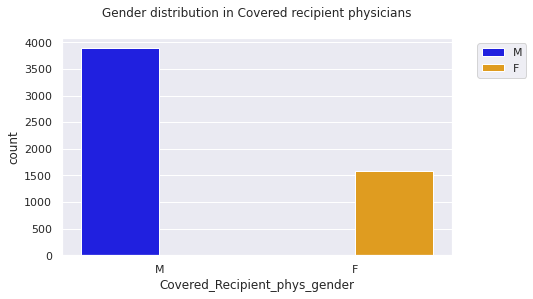

In [187]:
# Function by profile id
create_chart_gender(CR_physicians_gender, 'Covered_Recipient_phys_gender', 'count', 'Covered_Recipient_phys_gender', 
                    'Gender distribution in Covered recipient physicians\n', 'count')

In [188]:
# Total by gender based payments
CR_physicians_gender_pay=CR_physicians_all.groupby(['Covered_Recipient_phys_gender'])['Dist_total_Payment_in_USD'].sum().reset_index()

CR_physicians_gender_pay


,Covered_Recipient_phys_gender,Dist_total_Payment_in_USD
0,F,17348851.39
1,M,53978203.74


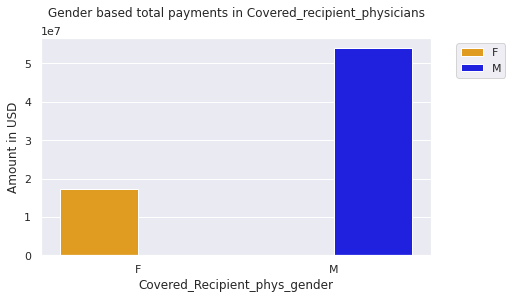

In [189]:
create_chart_gender(CR_physicians_gender_pay, 'Covered_Recipient_phys_gender', 'Dist_total_Payment_in_USD', 'Covered_Recipient_phys_gender', 
                    'Gender based total payments in Covered_recipient_physicians\n', 'Amount in USD')


In [190]:
# Total by individuals & gender based payments
CR_physicians_individuals=CR_physicians_all.groupby(['Covered_Recipient_phys_gender','Covered_Recipient_phys_Profile_ID'])['Dist_total_Payment_in_USD'].sum().sort_values(ascending=False).reset_index()

CR_physicians_individuals


,Covered_Recipient_phys_gender,Covered_Recipient_phys_Profile_ID,Dist_total_Payment_in_USD
0,M,565647.0,1247560.39
1,M,701937.0,840559.50
2,M,49989.0,683830.05
3,M,708599.0,651062.00
4,M,85984.0,646130.24
...,...,...,...
5460,M,216875.0,2.02
5461,M,1337767.0,2.02
5462,M,20970.0,2.02
5463,M,486570.0,2.02


In [191]:
CR_physicians_individuals[:50].describe(include=object)

,Covered_Recipient_phys_gender,Covered_Recipient_phys_Profile_ID
count,50,50
unique,2,50
top,M,565647.0
freq,37,1


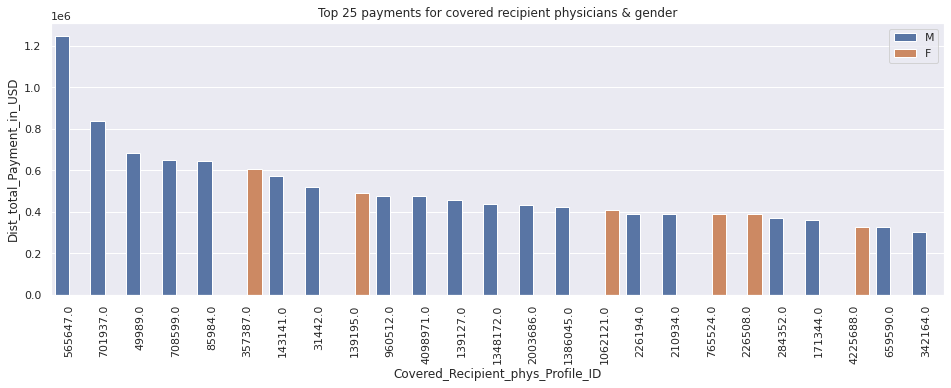

In [192]:
sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=CR_physicians_individuals[:25], x='Covered_Recipient_phys_Profile_ID', y='Dist_total_Payment_in_USD', hue='Covered_Recipient_phys_gender', 
              order=CR_physicians_individuals[:25].sort_values('Dist_total_Payment_in_USD', ascending=False).Covered_Recipient_phys_Profile_ID, palette=my_palette)
g.set(title='Top 25 payments for covered recipient physicians & gender')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');


In [193]:
# Total by individuals & gender based payments
CR_physicians_form_gender=CR_physicians_all.groupby(['Covered_Recipient_phys_gender','Form_of_Payment_or_Transfer_of_Value'])['Dist_total_Payment_in_USD'].sum().sort_values(ascending=False).reset_index()

CR_physicians_form_gender


,Covered_Recipient_phys_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
0,M,Cash or cash equivalent,47614752.61
1,F,Cash or cash equivalent,14231078.87
2,M,In-kind items and services,6363451.13
3,F,In-kind items and services,3117772.52


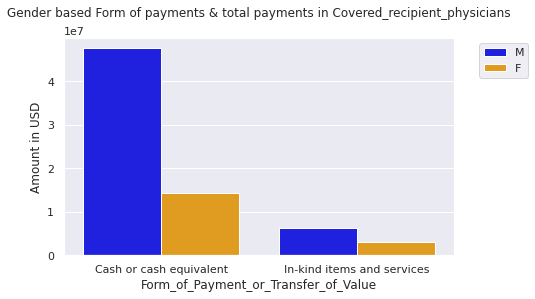

In [194]:
create_chart_gender(CR_physicians_form_gender, 'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD', 'Covered_Recipient_phys_gender', 
                    'Gender based Form of payments & total payments in Covered_recipient_physicians\n', 'Amount in USD')


In [195]:
# Total by individuals & gender based payments and form of payment
CR_physicians_form_ind=CR_physicians_all.groupby(['Covered_Recipient_phys_gender','Form_of_Payment_or_Transfer_of_Value','Covered_Recipient_phys_Profile_ID'])['Dist_total_Payment_in_USD'].sum().sort_values(ascending=False).reset_index()

CR_physicians_form_ind


,Covered_Recipient_phys_gender,Form_of_Payment_or_Transfer_of_Value,Covered_Recipient_phys_Profile_ID,Dist_total_Payment_in_USD
0,M,Cash or cash equivalent,565647.0,1247560.39
1,M,Cash or cash equivalent,701937.0,840559.50
2,M,Cash or cash equivalent,49989.0,683830.05
3,M,Cash or cash equivalent,708599.0,651062.00
4,M,Cash or cash equivalent,85984.0,646130.24
...,...,...,...,...
5921,F,In-kind items and services,357288.0,2.02
5922,M,In-kind items and services,486570.0,2.02
5923,M,In-kind items and services,216875.0,2.02
5924,M,In-kind items and services,20970.0,2.02


In [196]:
CR_physicians_form_kind=CR_physicians_form_ind[CR_physicians_form_ind['Form_of_Payment_or_Transfer_of_Value']=='In-kind items and services'].sort_values(by='Dist_total_Payment_in_USD',ascending=False)[:50]
CR_physicians_form_kind


,Covered_Recipient_phys_gender,Form_of_Payment_or_Transfer_of_Value,Covered_Recipient_phys_Profile_ID,Dist_total_Payment_in_USD
34,M,In-kind items and services,226194.0,251477.81
98,F,In-kind items and services,158261.0,131216.93
99,F,In-kind items and services,932767.0,128817.03
128,M,In-kind items and services,171344.0,106427.20
174,M,In-kind items and services,277183.0,81660.00
209,M,In-kind items and services,1064.0,71352.28
256,M,In-kind items and services,82778.0,61612.46
281,M,In-kind items and services,362051.0,54273.42
303,M,In-kind items and services,11507.0,50795.33
304,F,In-kind items and services,43132.0,50497.72


In [197]:
CR_physicians_form_kind[:50].describe(include=object)

,Covered_Recipient_phys_gender,Form_of_Payment_or_Transfer_of_Value,Covered_Recipient_phys_Profile_ID
count,50,50,50
unique,2,1,50
top,M,In-kind items and services,226194.0
freq,36,50,1


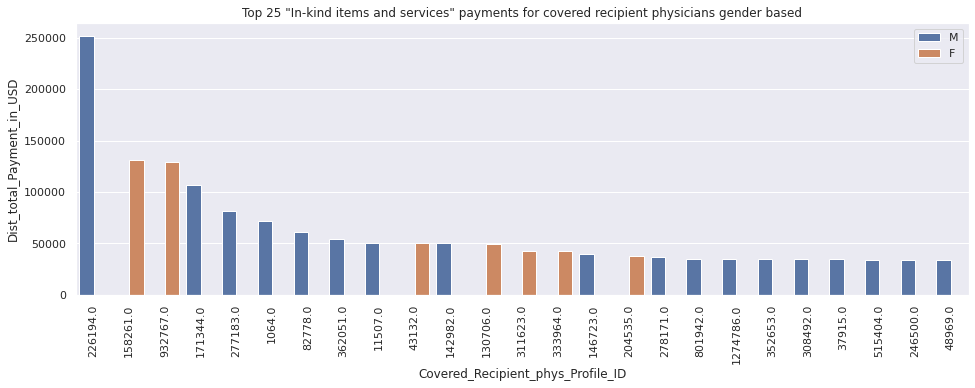

In [198]:
sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=CR_physicians_form_kind[:25], x='Covered_Recipient_phys_Profile_ID', y='Dist_total_Payment_in_USD', hue='Covered_Recipient_phys_gender', 
              order=CR_physicians_form_kind[:25].sort_values('Dist_total_Payment_in_USD', ascending=False).Covered_Recipient_phys_Profile_ID, palette=my_palette)
g.set(title='Top 25 "In-kind items and services" payments for covered recipient physicians gender based')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');


In [199]:
CR_physicians_form_cash=CR_physicians_form_ind[CR_physicians_form_ind['Form_of_Payment_or_Transfer_of_Value']=='Cash or cash equivalent'].sort_values(by='Dist_total_Payment_in_USD',ascending=False)[:50]
CR_physicians_form_cash


,Covered_Recipient_phys_gender,Form_of_Payment_or_Transfer_of_Value,Covered_Recipient_phys_Profile_ID,Dist_total_Payment_in_USD
0,M,Cash or cash equivalent,565647.0,1247560.390
1,M,Cash or cash equivalent,701937.0,840559.500
2,M,Cash or cash equivalent,49989.0,683830.050
3,M,Cash or cash equivalent,708599.0,651062.000
4,M,Cash or cash equivalent,85984.0,646130.240
5,F,Cash or cash equivalent,357387.0,604756.500
6,M,Cash or cash equivalent,143141.0,568958.030
7,M,Cash or cash equivalent,31442.0,521252.790
8,F,Cash or cash equivalent,139195.0,489970.000
9,M,Cash or cash equivalent,960512.0,477800.000


In [200]:
CR_physicians_form_cash[:50].describe(include=object)

,Covered_Recipient_phys_gender,Form_of_Payment_or_Transfer_of_Value,Covered_Recipient_phys_Profile_ID
count,50,50,50
unique,2,1,50
top,M,Cash or cash equivalent,565647.0
freq,37,50,1


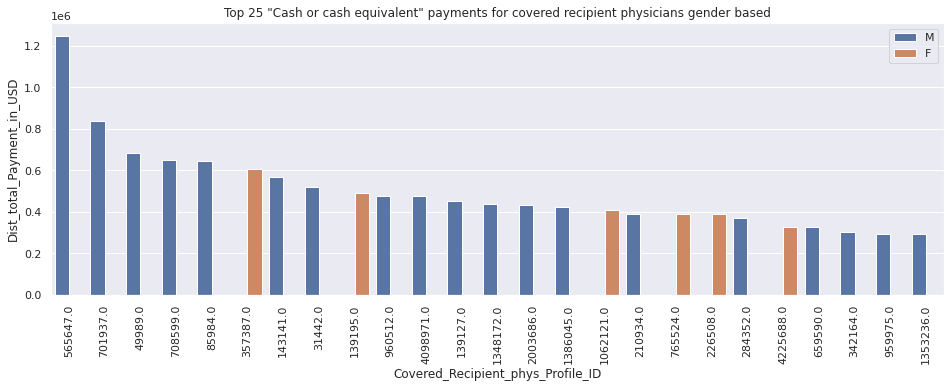

In [201]:
sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=CR_physicians_form_cash[:25], x='Covered_Recipient_phys_Profile_ID', y='Dist_total_Payment_in_USD', hue='Covered_Recipient_phys_gender', 
              order=CR_physicians_form_cash[:25].sort_values('Dist_total_Payment_in_USD', ascending=False).Covered_Recipient_phys_Profile_ID, palette=my_palette)
g.set(title='Top 25 "Cash or cash equivalent" payments for covered recipient physicians gender based')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');


In [202]:
# Mean by gender based payments
CR_physicians_gender_pay_mean=CR_physicians_all.groupby(['Covered_Recipient_phys_gender'])['Dist_total_Payment_in_USD'].mean().sort_values(ascending=False).reset_index()

CR_physicians_gender_pay_mean


,Covered_Recipient_phys_gender,Dist_total_Payment_in_USD
0,M,2982.715574
1,F,2427.431284


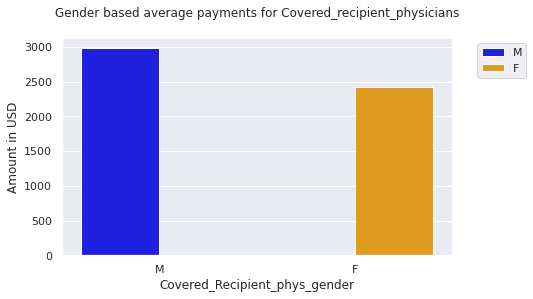

In [203]:
create_chart_gender(CR_physicians_gender_pay_mean, 'Covered_Recipient_phys_gender', 'Dist_total_Payment_in_USD', 'Covered_Recipient_phys_gender', 
                    'Gender based average payments for Covered_recipient_physicians\n', 'Amount in USD')


In [204]:
# Mean by gender based payments
CR_physicians_gender_form_mean=CR_physicians_all.groupby(['Covered_Recipient_phys_gender','Form_of_Payment_or_Transfer_of_Value'])['Dist_total_Payment_in_USD'].mean().sort_values(ascending=False).reset_index()

CR_physicians_gender_form_mean


,Covered_Recipient_phys_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
0,M,Cash or cash equivalent,5012.606865
1,F,Cash or cash equivalent,4699.827896
2,F,In-kind items and services,756.924622
3,M,In-kind items and services,740.108296


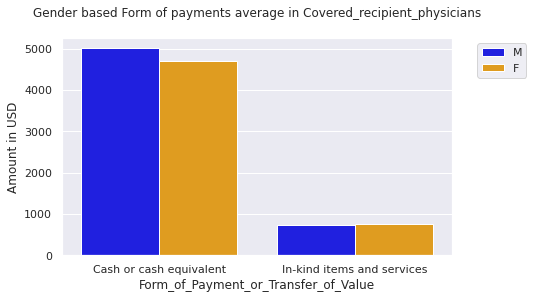

In [205]:
create_chart_gender(CR_physicians_gender_form_mean, 'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD', 'Covered_Recipient_phys_gender', 
                    'Gender based Form of payments average in Covered_recipient_physicians\n', 'Amount in USD')


In [206]:
# Median by gender based payments
CR_physicians_gender_pay_median=CR_physicians_all.groupby(['Covered_Recipient_phys_gender'])['Dist_total_Payment_in_USD'].median().sort_values(ascending=False).reset_index()

CR_physicians_gender_pay_median


,Covered_Recipient_phys_gender,Dist_total_Payment_in_USD
0,M,519.24
1,F,386.35


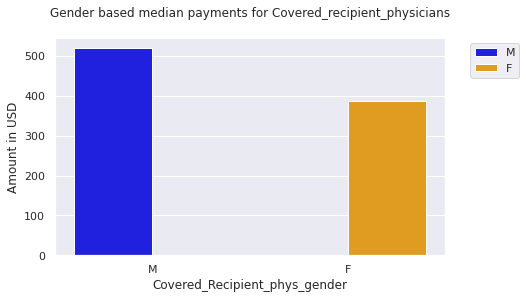

In [207]:
create_chart_gender(CR_physicians_gender_pay_median, 'Covered_Recipient_phys_gender', 'Dist_total_Payment_in_USD', 'Covered_Recipient_phys_gender', 
                    'Gender based median payments for Covered_recipient_physicians\n','Amount in USD')




In [208]:
# Median by gender based payments
CR_physicians_gender_form_median=CR_physicians_all.groupby(['Covered_Recipient_phys_gender','Form_of_Payment_or_Transfer_of_Value'])['Dist_total_Payment_in_USD'].median().sort_values(ascending=False).reset_index()

CR_physicians_gender_form_median



,Covered_Recipient_phys_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
0,M,Cash or cash equivalent,1038.82
1,F,Cash or cash equivalent,868.00
2,F,In-kind items and services,300.00
3,M,In-kind items and services,300.00


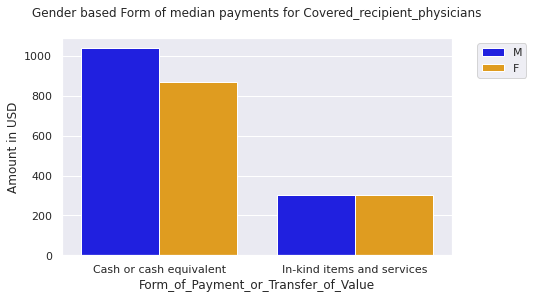

In [209]:
create_chart_gender(CR_physicians_gender_form_median, 'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD', 'Covered_Recipient_phys_gender', 
                    'Gender based Form of median payments for Covered_recipient_physicians\n', 'Amount in USD')

## Covered recipient non-physician 

In [210]:
# Verifying features of all entities
CR_non_physicians = df_research[df_research['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner'][[ 'Covered_Recipient_Profile_ID', 
                          'Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          'Principal_Investigator_4_Profile_ID','Principal_Investigator_5_Profile_ID', 'Payee_num', 'Covered_Recipient_gender',                                                                                                                                                                    
                          'Principal_Investigator_1_gender',  'Principal_Investigator_2_gender','Principal_Investigator_3_gender', 'Principal_Investigator_4_gender',  
                          'Principal_Investigator_5_gender', 'Name_of_Study', 'ClinicalTrials_Gov_Identifier',
                          'Research_Information_Link', 'Context_of_Research','Form_of_Payment_or_Transfer_of_Value','Dist_total_Payment_in_USD','Total_Amount_of_Payment_USDollars']]



In [211]:
CR_non_physicians.describe()

,Payee_num,Dist_total_Payment_in_USD,Total_Amount_of_Payment_USDollars
count,1168.000000,1168.000000,1168.000000
mean,1.011130,452.946811,455.068682
std,0.104956,1541.513052,1543.986723
min,1.000000,1.750000,1.750000
25%,1.000000,50.000000,50.000000
50%,1.000000,102.650000,103.345000
75%,1.000000,298.267500,300.000000
max,2.000000,21685.000000,21685.000000


In [212]:
CR_non_physicians.describe(include=object)

,Covered_Recipient_Profile_ID,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID,Principal_Investigator_3_Profile_ID,Principal_Investigator_4_Profile_ID,Principal_Investigator_5_Profile_ID,Covered_Recipient_gender,Principal_Investigator_1_gender,Principal_Investigator_2_gender,Principal_Investigator_3_gender,Principal_Investigator_4_gender,Principal_Investigator_5_gender,Name_of_Study,ClinicalTrials_Gov_Identifier,Research_Information_Link,Context_of_Research,Form_of_Payment_or_Transfer_of_Value
count,1168,13,0,0,0,0,1168,13,0,0,0,0,1162,329,12,238,1168
unique,226,2,0,0,0,0,2,2,0,0,0,0,112,26,8,16,2
top,10787297.0,1154426955.0,NaN,NaN,NaN,NaN,F,F,NaN,NaN,NaN,NaN,lvans,NCT06130566,https://clinicaltrials.gov/study/NCT05467072?i...,m23-696,In-kind items and services
freq,19,12,NaN,NaN,NaN,NaN,924,12,NaN,NaN,NaN,NaN,102,85,4,46,915


In [213]:
### There are grouped payments with principal investigaters 1
CR_non_physicians[CR_non_physicians['Payee_num']== 2][['Covered_Recipient_Profile_ID','Principal_Investigator_1_Profile_ID','Principal_Investigator_2_Profile_ID',
                                             'Principal_Investigator_3_Profile_ID','Principal_Investigator_4_Profile_ID',
                                             'Principal_Investigator_5_Profile_ID','Payee_num','Form_of_Payment_or_Transfer_of_Value',
                                             'Dist_total_Payment_in_USD','Total_Amount_of_Payment_USDollars'
                                            ]]

,Covered_Recipient_Profile_ID,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID,Principal_Investigator_3_Profile_ID,Principal_Investigator_4_Profile_ID,Principal_Investigator_5_Profile_ID,Payee_num,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD,Total_Amount_of_Payment_USDollars
3137,10471325.0,1154426955.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,70.000,140.00
7047,10471325.0,1154426955.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,123.190,246.38
9475,10471325.0,1154426955.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,22.495,44.99
10081,10471325.0,1154426955.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,7.500,15.00
15044,10471325.0,1154426955.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,15.000,30.00
19604,10471325.0,1154426955.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,7.500,15.00
25323,10471325.0,1154426955.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,19.325,38.65
26168,10471325.0,1154426955.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,185.840,371.68
30319,10471325.0,1154426955.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,70.000,140.00
31814,10471325.0,1154426955.0,NaN,NaN,NaN,NaN,2,Cash or cash equivalent,15.000,30.00


In [214]:
df_research.iloc[112672][['Covered_Recipient_gender','Principal_Investigator_1_gender' ]]

Covered_Recipient_gender           M
Principal_Investigator_1_gender    M
Name: 112672, dtype: object

**13 payments to non_phyciacian and investigators together with max value 3825 USD to 1 pair**

In [215]:
# Sorting for better view of top payments
CR_non_physicians=CR_non_physicians.sort_values(by='Total_Amount_of_Payment_USDollars', ascending=False)


CR_non_physicians[:40][['Payee_num','Dist_total_Payment_in_USD','Total_Amount_of_Payment_USDollars']]


,Payee_num,Dist_total_Payment_in_USD,Total_Amount_of_Payment_USDollars
4109,1,21685.00,21685.00
129368,1,14500.00,14500.00
62942,1,14257.56,14257.56
19949,1,13500.00,13500.00
127827,1,13400.00,13400.00
36093,1,13065.00,13065.00
140934,1,11310.63,11310.63
141002,1,11130.00,11130.00
19605,1,10114.80,10114.80
113872,1,10114.80,10114.80


#### 112672 3825$ comes under top 40 and is significant in this category

In [216]:
CR_non_physicians_1=CR_non_physicians[['Covered_Recipient_Profile_ID','Covered_Recipient_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]

CR_non_physicians_1=CR_non_physicians_1.rename(columns={'Covered_Recipient_Profile_ID':'Covered_Recipient_nonphys_Profile_ID',
                                           'Covered_Recipient_gender': 'Covered_Recipient_non_phys_gender'
                                           })

CR_non_physicians_1.describe(include=object)


,Covered_Recipient_nonphys_Profile_ID,Covered_Recipient_non_phys_gender,Form_of_Payment_or_Transfer_of_Value
count,1168,1168,1168
unique,226,2,2
top,10787297.0,F,In-kind items and services
freq,19,924,915


In [217]:
CR_non_physicians_2=CR_non_physicians[['Principal_Investigator_1_Profile_ID','Principal_Investigator_1_gender',
                                                'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD']]

CR_non_physicians_2=CR_non_physicians_2.rename(columns={'Principal_Investigator_1_Profile_ID':'Covered_Recipient_nonphys_Profile_ID',
                                           'Principal_Investigator_1_gender': 'Covered_Recipient_non_phys_gender'
                                           })

CR_non_physicians_2.describe(include=object)


,Covered_Recipient_nonphys_Profile_ID,Covered_Recipient_non_phys_gender,Form_of_Payment_or_Transfer_of_Value
count,13,13,1168
unique,2,2,2
top,1154426955.0,F,In-kind items and services
freq,12,12,915


In [218]:
CR_non_physicians_all=pd.concat([CR_non_physicians_1, CR_non_physicians_2])
CR_non_physicians_all  



,Covered_Recipient_nonphys_Profile_ID,Covered_Recipient_non_phys_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
4109,10726994.0,M,Cash or cash equivalent,21685.00
129368,10924490.0,F,Cash or cash equivalent,14500.00
62942,11123592.0,F,In-kind items and services,14257.56
19949,11168280.0,M,Cash or cash equivalent,13500.00
127827,10924490.0,F,Cash or cash equivalent,13400.00
...,...,...,...,...
114442,NaN,NaN,In-kind items and services,2.12
40036,NaN,NaN,In-kind items and services,2.12
31864,NaN,NaN,In-kind items and services,1.75
29673,NaN,NaN,In-kind items and services,1.75


In [219]:
# should be twice
1168*2

2336

In [220]:
CR_non_physicians_all=CR_non_physicians_all[CR_non_physicians_all['Covered_Recipient_nonphys_Profile_ID'].notna()]
CR_non_physicians_all

,Covered_Recipient_nonphys_Profile_ID,Covered_Recipient_non_phys_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
4109,10726994.0,M,Cash or cash equivalent,21685.00
129368,10924490.0,F,Cash or cash equivalent,14500.00
62942,11123592.0,F,In-kind items and services,14257.56
19949,11168280.0,M,Cash or cash equivalent,13500.00
127827,10924490.0,F,Cash or cash equivalent,13400.00
...,...,...,...,...
15044,1154426955.0,F,Cash or cash equivalent,15.00
31814,1154426955.0,F,Cash or cash equivalent,15.00
10081,1154426955.0,F,Cash or cash equivalent,7.50
19604,1154426955.0,F,Cash or cash equivalent,7.50


In [221]:
CR_non_physicians_gender= CR_non_physicians_all.groupby(['Covered_Recipient_nonphys_Profile_ID','Covered_Recipient_non_phys_gender'])['Dist_total_Payment_in_USD'].sum().sort_values(ascending=False).reset_index()
CR_non_physicians_gender



,Covered_Recipient_nonphys_Profile_ID,Covered_Recipient_non_phys_gender,Dist_total_Payment_in_USD
0,10924490.0,F,44900.00
1,10414732.0,F,44019.12
2,10726994.0,M,23492.08
3,10683993.0,M,19775.00
4,11123592.0,F,15791.89
...,...,...,...
223,10884606.0,F,19.71
224,10740295.0,F,19.71
225,11144918.0,F,19.71
226,10623709.0,M,18.15


In [222]:
CR_non_physicians_gender[:50].describe(include=object)

,Covered_Recipient_nonphys_Profile_ID,Covered_Recipient_non_phys_gender
count,50,50
unique,50,2
top,10924490.0,F
freq,1,39


In [223]:
CR_non_phys_gender_ratio=CR_non_physicians_gender.groupby('Covered_Recipient_non_phys_gender')['Covered_Recipient_nonphys_Profile_ID'].count().reset_index()

CR_non_phys_gender_ratio

,Covered_Recipient_non_phys_gender,Covered_Recipient_nonphys_Profile_ID
0,F,171
1,M,57


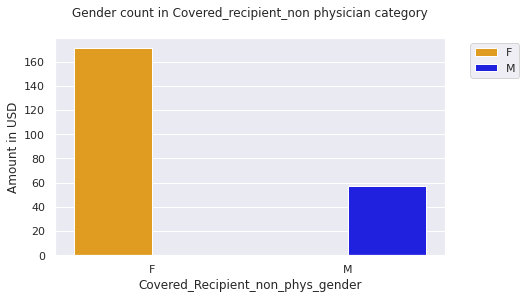

In [224]:
create_chart_gender(CR_non_phys_gender_ratio, 'Covered_Recipient_non_phys_gender', 'Covered_Recipient_nonphys_Profile_ID', 'Covered_Recipient_non_phys_gender', 
                    'Gender count in Covered_recipient_non physician category\n', 'Amount in USD')


In [225]:
# Total by gender based payments
CR_non_physicians_gender_pay=CR_non_physicians_all.groupby(['Covered_Recipient_non_phys_gender'])['Dist_total_Payment_in_USD'].sum().reset_index()

CR_non_physicians_gender_pay



,Covered_Recipient_non_phys_gender,Dist_total_Payment_in_USD
0,F,404343.95
1,M,127176.27


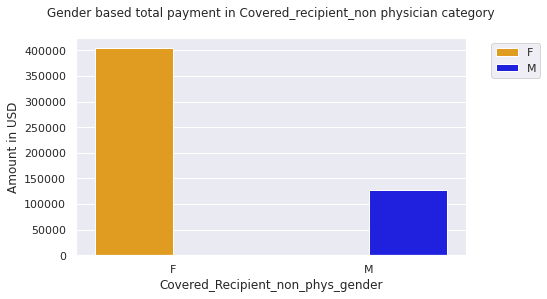

In [226]:
create_chart_gender(CR_non_physicians_gender_pay, 'Covered_Recipient_non_phys_gender', 'Dist_total_Payment_in_USD', 'Covered_Recipient_non_phys_gender', 
                    'Gender based total payment in Covered_recipient_non physician category\n','Amount in USD')


In [227]:
# Total by individuals & gender based payments
CR_non_physicians_form=CR_non_physicians_all.groupby(['Covered_Recipient_non_phys_gender','Form_of_Payment_or_Transfer_of_Value'])['Dist_total_Payment_in_USD'].sum().sort_values(ascending=False).reset_index()

CR_non_physicians_form

,Covered_Recipient_non_phys_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
0,F,In-kind items and services,247303.98
1,F,Cash or cash equivalent,157039.97
2,M,Cash or cash equivalent,87800.12
3,M,In-kind items and services,39376.15


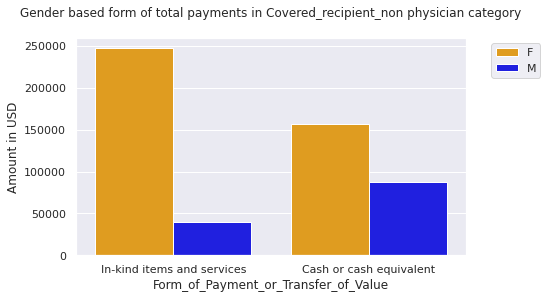

In [228]:
create_chart_gender(CR_non_physicians_form, 'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD', 'Covered_Recipient_non_phys_gender', 
                    'Gender based form of total payments in Covered_recipient_non physician category\n','Amount in USD')



In [229]:
# Total by individuals & gender based payments
CR_non_physicians_form_ind=CR_non_physicians_all.groupby(['Covered_Recipient_non_phys_gender','Form_of_Payment_or_Transfer_of_Value', 'Covered_Recipient_nonphys_Profile_ID'])['Dist_total_Payment_in_USD'].sum().sort_values(ascending=False).reset_index()




In [230]:
# By top 25 payee & gender form of payment - cash or cash equivalent

CR_nonphys_cash=CR_non_physicians_form_ind[CR_non_physicians_form_ind['Form_of_Payment_or_Transfer_of_Value']=='Cash or cash equivalent'].sort_values('Dist_total_Payment_in_USD', ascending=False)[:50]
CR_nonphys_cash.describe(include=object)


,Covered_Recipient_non_phys_gender,Form_of_Payment_or_Transfer_of_Value,Covered_Recipient_nonphys_Profile_ID
count,50,50,50
unique,2,1,50
top,F,Cash or cash equivalent,10924490.0
freq,32,50,1


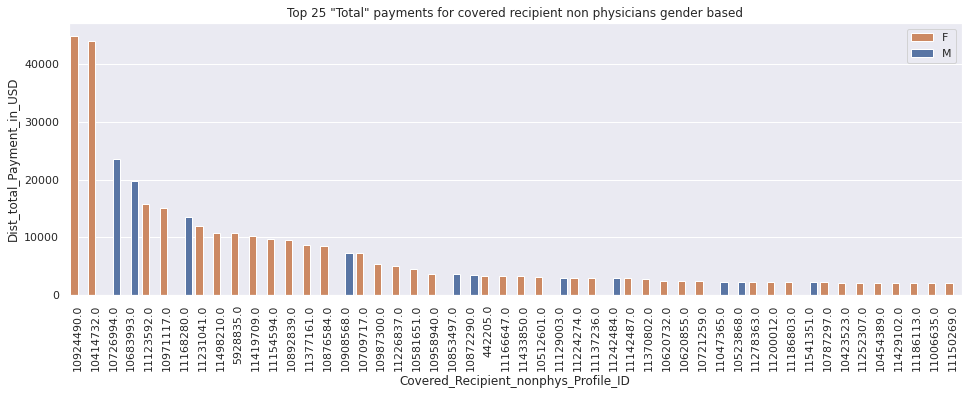

In [231]:

sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=CR_non_physicians_gender[:50], x='Covered_Recipient_nonphys_Profile_ID', y='Dist_total_Payment_in_USD', hue='Covered_Recipient_non_phys_gender', 
              order=CR_non_physicians_gender[:50].sort_values('Dist_total_Payment_in_USD', ascending=False).Covered_Recipient_nonphys_Profile_ID, palette=my_palette)
g.set(title='Top 25 "Total" payments for covered recipient non physicians gender based')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');



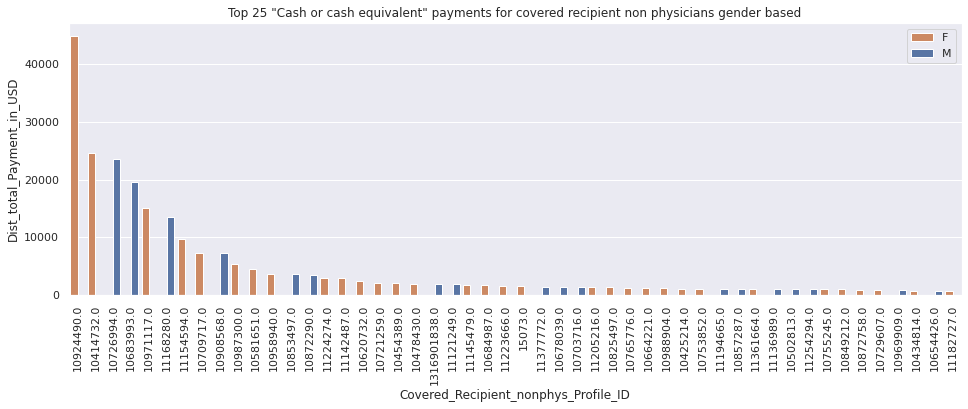

In [232]:
sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=CR_nonphys_cash, x='Covered_Recipient_nonphys_Profile_ID', y='Dist_total_Payment_in_USD', hue='Covered_Recipient_non_phys_gender', 
              order=CR_nonphys_cash.sort_values('Dist_total_Payment_in_USD', ascending=False).Covered_Recipient_nonphys_Profile_ID, palette=my_palette)
g.set(title='Top 25 "Cash or cash equivalent" payments for covered recipient non physicians gender based')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');


In [233]:
# By top 25 payee & gender form of payment - cash or cash equivalent

CR_nonphys_inkind=CR_non_physicians_form_ind[CR_non_physicians_form_ind['Form_of_Payment_or_Transfer_of_Value']=='In-kind items and services'].sort_values('Dist_total_Payment_in_USD', ascending=False)[:50]
CR_nonphys_inkind.describe(include=object)



,Covered_Recipient_non_phys_gender,Form_of_Payment_or_Transfer_of_Value,Covered_Recipient_nonphys_Profile_ID
count,50,50,50
unique,2,1,50
top,F,In-kind items and services,10414732.0
freq,40,50,1


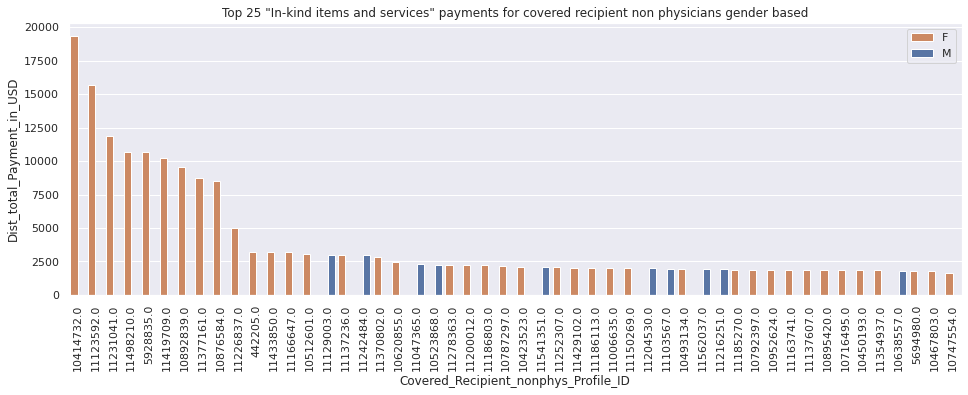

In [234]:
sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=CR_nonphys_inkind, x='Covered_Recipient_nonphys_Profile_ID', y='Dist_total_Payment_in_USD', hue='Covered_Recipient_non_phys_gender', 
              order=CR_nonphys_inkind.sort_values('Dist_total_Payment_in_USD', ascending=False).Covered_Recipient_nonphys_Profile_ID, palette=my_palette)
g.set(title='Top 25 "In-kind items and services" payments for covered recipient non physicians gender based')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');



In [235]:
# Average  by gender based payments
CR_non_physicians_gender_pay_mean=CR_non_physicians_all.groupby(['Covered_Recipient_non_phys_gender'])['Dist_total_Payment_in_USD'].mean().reset_index()

CR_non_physicians_gender_pay_mean

,Covered_Recipient_non_phys_gender,Dist_total_Payment_in_USD
0,F,431.991400
1,M,519.086816


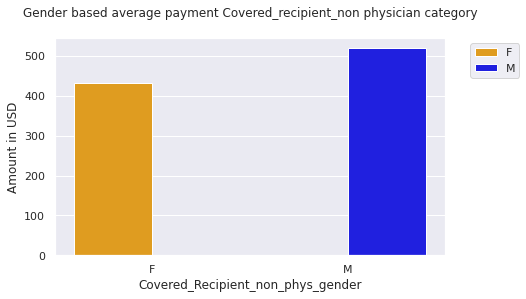

In [236]:
create_chart_gender(CR_non_physicians_gender_pay_mean, 'Covered_Recipient_non_phys_gender', 'Dist_total_Payment_in_USD', 'Covered_Recipient_non_phys_gender', 
                    'Gender based average payment Covered_recipient_non physician category\n', 'Amount in USD')


In [237]:
# MEdian by gender based payments
CR_non_physicians_gender_pay_median=CR_non_physicians_all.groupby(['Covered_Recipient_non_phys_gender'])['Dist_total_Payment_in_USD'].median().reset_index()

CR_non_physicians_gender_pay_median


,Covered_Recipient_non_phys_gender,Dist_total_Payment_in_USD
0,F,100.07
1,M,108.35


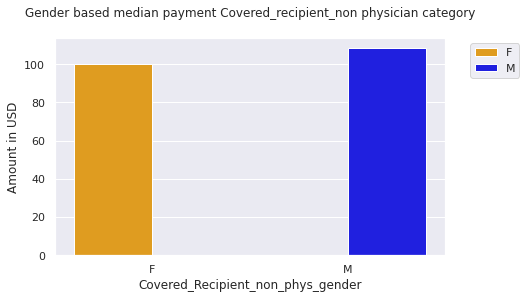

In [238]:
create_chart_gender(CR_non_physicians_gender_pay_median, 'Covered_Recipient_non_phys_gender', 'Dist_total_Payment_in_USD', 'Covered_Recipient_non_phys_gender', 
                    'Gender based median payment Covered_recipient_non physician category\n', 'Amount in USD')


In [239]:
# Average by individuals & gender based payments
CR_non_physicians_form_mean=CR_non_physicians_all.groupby(['Covered_Recipient_non_phys_gender','Form_of_Payment_or_Transfer_of_Value'])['Dist_total_Payment_in_USD'].mean().sort_values(ascending=False).reset_index()

CR_non_physicians_form_mean


,Covered_Recipient_non_phys_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
0,M,Cash or cash equivalent,1596.365818
1,F,Cash or cash equivalent,744.265261
2,F,In-kind items and services,341.108938
3,M,In-kind items and services,207.242895


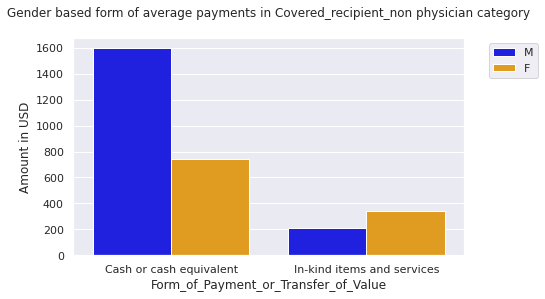

In [240]:
create_chart_gender(CR_non_physicians_form_mean, 'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD', 'Covered_Recipient_non_phys_gender', 
                    'Gender based form of average payments in Covered_recipient_non physician category\n','Amount in USD')


In [241]:
# Average by individuals & gender based payments
CR_non_physicians_form_median=CR_non_physicians_all.groupby(['Covered_Recipient_non_phys_gender','Form_of_Payment_or_Transfer_of_Value'])['Dist_total_Payment_in_USD'].median().sort_values(ascending=False).reset_index()

CR_non_physicians_form_median


,Covered_Recipient_non_phys_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
0,M,Cash or cash equivalent,258.000
1,F,In-kind items and services,107.480
2,F,Cash or cash equivalent,100.000
3,M,In-kind items and services,99.995


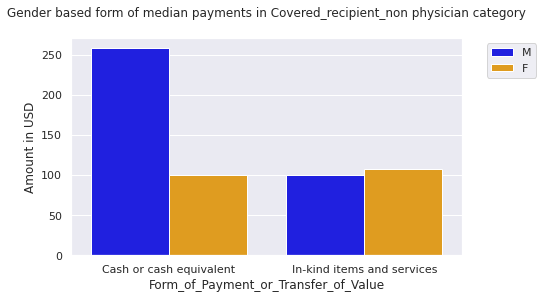

In [242]:
create_chart_gender(CR_non_physicians_form_median, 'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD', 'Covered_Recipient_non_phys_gender', 
                    'Gender based form of median payments in Covered_recipient_non physician category\n','Amount in USD')


### Non-covered Recipient Individual

In [243]:
df_research['Covered_Recipient_Type'].unique()

array(['Covered Recipient Teaching Hospital',
       'Covered Recipient Non-Physician Practitioner',
       'Covered Recipient Physician', 'Non-covered Recipient Entity',
       'Non-covered Recipient Individual'], dtype=object)

In [244]:
# Verifying features of all non covered individuals
NC_ind=df_research[df_research['Covered_Recipient_Type']=='Non-covered Recipient Individual'][['Noncovered_Recipient_Entity_Name',
                          'Principal_Investigator_1_Profile_ID', 'Principal_Investigator_2_Profile_ID' ,'Principal_Investigator_3_Profile_ID',
                          'Principal_Investigator_4_Profile_ID','Principal_Investigator_5_Profile_ID', 'Payee_num',                                                                                                                                                                     
                          'Principal_Investigator_1_gender',  'Principal_Investigator_2_gender','Principal_Investigator_3_gender', 'Principal_Investigator_4_gender',  
                          'Principal_Investigator_5_gender', 'Name_of_Study', 'ClinicalTrials_Gov_Identifier',
                          'Research_Information_Link', 'Context_of_Research','Form_of_Payment_or_Transfer_of_Value','Dist_total_Payment_in_USD','Total_Amount_of_Payment_USDollars']]



In [245]:
# Sorting for better view of top payments
NC_ind=NC_ind.sort_values(by='Total_Amount_of_Payment_USDollars', ascending=False)

NC_ind.describe()

,Payee_num,Dist_total_Payment_in_USD,Total_Amount_of_Payment_USDollars
count,70.0,70.000000,70.000000
mean,1.0,12137.404286,12137.404286
std,0.0,24649.389694,24649.389694
min,1.0,15.000000,15.000000
25%,1.0,140.000000,140.000000
50%,1.0,1800.000000,1800.000000
75%,1.0,13256.450000,13256.450000
max,1.0,152431.000000,152431.000000


In [246]:
NC_ind.describe(include=object)

,Noncovered_Recipient_Entity_Name,Principal_Investigator_1_Profile_ID,Principal_Investigator_2_Profile_ID,Principal_Investigator_3_Profile_ID,Principal_Investigator_4_Profile_ID,Principal_Investigator_5_Profile_ID,Principal_Investigator_1_gender,Principal_Investigator_2_gender,Principal_Investigator_3_gender,Principal_Investigator_4_gender,Principal_Investigator_5_gender,Name_of_Study,ClinicalTrials_Gov_Identifier,Research_Information_Link,Context_of_Research,Form_of_Payment_or_Transfer_of_Value
count,0,70,0,0,0,0,70,0,0,0,0,70,33,0,18,70
unique,0,22,0,0,0,0,2,0,0,0,0,20,11,0,1,2
top,NaN,1548291834.0,NaN,NaN,NaN,NaN,M,NaN,NaN,NaN,NaN,"a multinational, multicenter, randomized, doub...",NCT05329129,NaN,patient outcomes,Cash or cash equivalent
freq,NaN,11,NaN,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,22,16,NaN,18,68


In [247]:
NC_ind.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70 entries, 579454 to 1017386
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Noncovered_Recipient_Entity_Name      0 non-null      object 
 1   Principal_Investigator_1_Profile_ID   70 non-null     object 
 2   Principal_Investigator_2_Profile_ID   0 non-null      object 
 3   Principal_Investigator_3_Profile_ID   0 non-null      object 
 4   Principal_Investigator_4_Profile_ID   0 non-null      object 
 5   Principal_Investigator_5_Profile_ID   0 non-null      object 
 6   Payee_num                             70 non-null     int64  
 7   Principal_Investigator_1_gender       70 non-null     object 
 8   Principal_Investigator_2_gender       0 non-null      object 
 9   Principal_Investigator_3_gender       0 non-null      object 
 10  Principal_Investigator_4_gender       0 non-null      object 
 11  Principal_Invest

## Non covered recipient individuals have profile id as principal investigater 1

In [248]:
NC_ind_gender= NC_ind.groupby(['Principal_Investigator_1_Profile_ID','Principal_Investigator_1_gender'])['Total_Amount_of_Payment_USDollars'].sum().reset_index()
NC_ind_gender



,Principal_Investigator_1_Profile_ID,Principal_Investigator_1_gender,Total_Amount_of_Payment_USDollars
0,1083052633.0,M,16530.00
1,1134206709.0,M,56253.60
2,1154396901.0,M,6037.00
3,1164428090.0,M,1050.00
4,1164467122.0,M,2464.00
5,1235457961.0,M,3000.00
6,1275746596.0,F,5000.00
7,1386865426.0,M,135990.00
8,1407892250.0,M,958.50
9,1437109907.0,M,5900.00


In [249]:
NC_gender=NC_ind_gender.groupby('Principal_Investigator_1_gender')['Principal_Investigator_1_Profile_ID'].count().reset_index()
NC_gender


,Principal_Investigator_1_gender,Principal_Investigator_1_Profile_ID
0,F,4
1,M,18


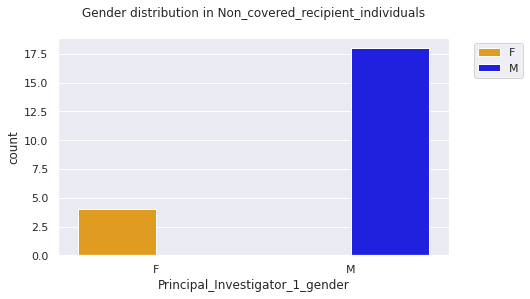

In [250]:
# Function 
create_chart_gender(NC_gender, 'Principal_Investigator_1_gender', 'Principal_Investigator_1_Profile_ID', 'Principal_Investigator_1_gender', 
                    'Gender distribution in Non_covered_recipient_individuals\n','count')


In [251]:
# Total by gender based payments
NC_ind_gender_pay=NC_ind.groupby(['Principal_Investigator_1_gender'])['Dist_total_Payment_in_USD'].sum().reset_index()

NC_ind_gender_pay


,Principal_Investigator_1_gender,Dist_total_Payment_in_USD
0,F,36579.71
1,M,813038.59


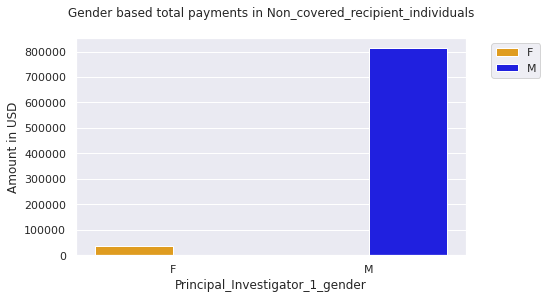

In [252]:
# gender based payments
create_chart_gender(NC_ind_gender_pay, 'Principal_Investigator_1_gender', 'Dist_total_Payment_in_USD', 'Principal_Investigator_1_gender', 
                    'Gender based total payments in Non_covered_recipient_individuals\n', 'Amount in USD')



In [253]:
# Total by gender based form of payments
NC_ind_gender_form_pay=NC_ind.groupby(['Principal_Investigator_1_gender','Form_of_Payment_or_Transfer_of_Value'])['Dist_total_Payment_in_USD'].sum().reset_index()

NC_ind_gender_form_pay


,Principal_Investigator_1_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
0,F,Cash or cash equivalent,36579.71
1,M,Cash or cash equivalent,812036.29
2,M,In-kind items and services,1002.30


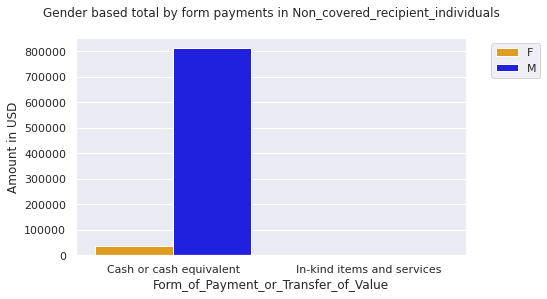

In [254]:
# gender based payments
create_chart_gender(NC_ind_gender_form_pay, 'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD', 'Principal_Investigator_1_gender', 
                    'Gender based total by form payments in Non_covered_recipient_individuals\n', 'Amount in USD')



In [255]:
# Total by individuals & gender based payments
NC_ind_individuals=NC_ind.groupby(['Principal_Investigator_1_gender','Principal_Investigator_1_Profile_ID'])['Dist_total_Payment_in_USD'].sum().sort_values(ascending=False).reset_index()

NC_ind_individuals


,Principal_Investigator_1_gender,Principal_Investigator_1_Profile_ID,Dist_total_Payment_in_USD
0,M,1447259023.0,285177.40
1,M,1790760783.0,172865.65
2,M,1386865426.0,135990.00
3,M,1760410351.0,85267.43
4,M,1134206709.0,56253.60
5,F,1679518435.0,27631.20
6,M,1083052633.0,16530.00
7,M,1477811826.0,16360.00
8,M,1932527298.0,10750.00
9,M,1447231725.0,6675.00


In [256]:
NC_ind_individuals[:50].describe(include=object)

,Principal_Investigator_1_gender,Principal_Investigator_1_Profile_ID
count,22,22
unique,2,22
top,M,1447259023.0
freq,18,1


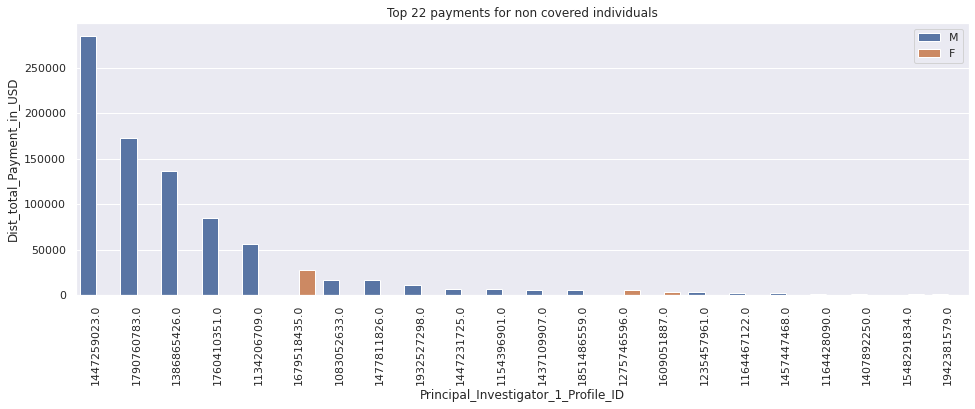

In [273]:
sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=NC_ind_individuals[:22], x='Principal_Investigator_1_Profile_ID', y='Dist_total_Payment_in_USD', hue='Principal_Investigator_1_gender', 
              order=NC_ind_individuals[:22].sort_values('Dist_total_Payment_in_USD', ascending=False).Principal_Investigator_1_Profile_ID, palette=my_palette)
g.set(title='Top 22 payments for non covered individuals')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');


In [272]:
# Total by gender based payments
NC_ind_form=NC_ind.groupby(['Principal_Investigator_1_Profile_ID','Form_of_Payment_or_Transfer_of_Value', 'Principal_Investigator_1_gender'])['Dist_total_Payment_in_USD'].sum().sort_values(ascending=False).reset_index()

NC_ind_form


,Principal_Investigator_1_Profile_ID,Form_of_Payment_or_Transfer_of_Value,Principal_Investigator_1_gender,Dist_total_Payment_in_USD
0,1447259023.0,Cash or cash equivalent,M,285133.60
1,1790760783.0,Cash or cash equivalent,M,172865.65
2,1386865426.0,Cash or cash equivalent,M,135990.00
3,1760410351.0,Cash or cash equivalent,M,85267.43
4,1134206709.0,Cash or cash equivalent,M,56253.60
5,1679518435.0,Cash or cash equivalent,F,27631.20
6,1083052633.0,Cash or cash equivalent,M,16530.00
7,1477811826.0,Cash or cash equivalent,M,16360.00
8,1932527298.0,Cash or cash equivalent,M,10750.00
9,1447231725.0,Cash or cash equivalent,M,6675.00


In [259]:
# By top 25 payee & gender form of payment - cash or cash equivalent

NC_ind_form_inkind=NC_ind_form[NC_ind_form['Form_of_Payment_or_Transfer_of_Value']=='In-kind items and services'].sort_values('Dist_total_Payment_in_USD', ascending=False)[:25]
NC_ind_form_inkind


,Principal_Investigator_1_Profile_ID,Form_of_Payment_or_Transfer_of_Value,Principal_Investigator_1_gender,Dist_total_Payment_in_USD
8,1407892250.0,In-kind items and services,M,958.5
12,1447259023.0,In-kind items and services,M,43.8


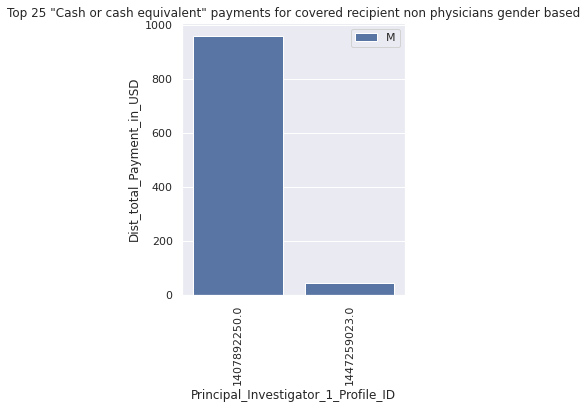

In [260]:
sns.set_theme(rc={'figure.figsize':(4,5)})
g=sns.barplot(data=NC_ind_form_inkind, x='Principal_Investigator_1_Profile_ID', y='Dist_total_Payment_in_USD', hue='Principal_Investigator_1_gender', 
              order=NC_ind_form_inkind.sort_values('Dist_total_Payment_in_USD', ascending=False).Principal_Investigator_1_Profile_ID, palette=my_palette)
g.set(title='Top 25 "Cash or cash equivalent" payments for covered recipient non physicians gender based')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');


In [261]:
# By top 25 payee & gender form of payment - cash or cash equivalent

NC_ind_form_cash=NC_ind_form[NC_ind_form['Form_of_Payment_or_Transfer_of_Value']=='Cash or cash equivalent'].sort_values('Dist_total_Payment_in_USD', ascending=False)[:25]
NC_ind_form_cash


,Principal_Investigator_1_Profile_ID,Form_of_Payment_or_Transfer_of_Value,Principal_Investigator_1_gender,Dist_total_Payment_in_USD
11,1447259023.0,Cash or cash equivalent,M,285133.60
19,1790760783.0,Cash or cash equivalent,M,172865.65
7,1386865426.0,Cash or cash equivalent,M,135990.00
18,1760410351.0,Cash or cash equivalent,M,85267.43
1,1134206709.0,Cash or cash equivalent,M,56253.60
17,1679518435.0,Cash or cash equivalent,F,27631.20
0,1083052633.0,Cash or cash equivalent,M,16530.00
14,1477811826.0,Cash or cash equivalent,M,16360.00
21,1932527298.0,Cash or cash equivalent,M,10750.00
10,1447231725.0,Cash or cash equivalent,M,6675.00


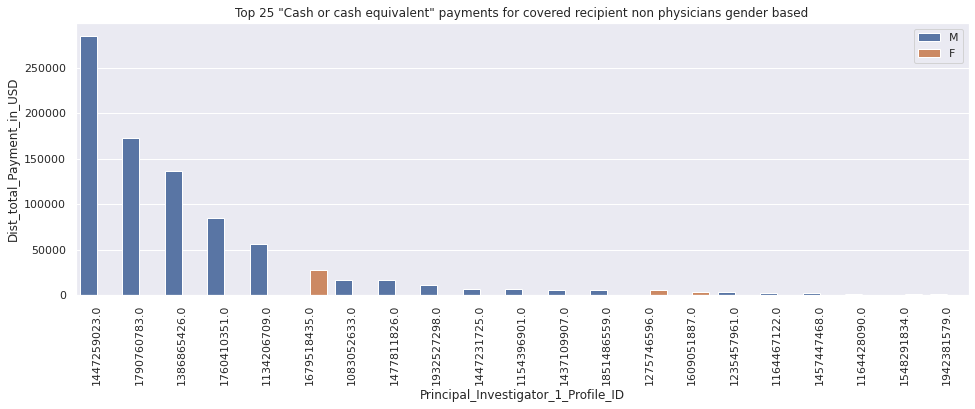

In [262]:
sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=NC_ind_form_cash, x='Principal_Investigator_1_Profile_ID', y='Dist_total_Payment_in_USD', hue='Principal_Investigator_1_gender', 
              order=NC_ind_form_cash.sort_values('Dist_total_Payment_in_USD', ascending=False).Principal_Investigator_1_Profile_ID, palette=my_palette)
g.set(title='Top 25 "Cash or cash equivalent" payments for covered recipient non physicians gender based')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');



In [263]:
# Total by gender based payments
NC_ind_gender_pay_avg=NC_ind.groupby(['Principal_Investigator_1_gender'])['Dist_total_Payment_in_USD'].mean().reset_index()

NC_ind_gender_pay_avg

,Principal_Investigator_1_gender,Dist_total_Payment_in_USD
0,F,2286.231875
1,M,15056.270185


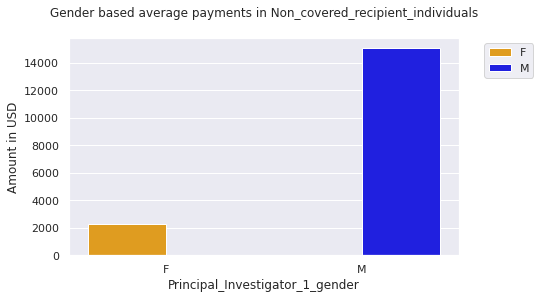

In [264]:
# gender based payments
create_chart_gender(NC_ind_gender_pay_avg, 'Principal_Investigator_1_gender', 'Dist_total_Payment_in_USD', 'Principal_Investigator_1_gender', 
                    'Gender based average payments in Non_covered_recipient_individuals\n', 'Amount in USD')



In [265]:
# Total by gender based form of payments
NC_ind_gender_form_pay_avg=NC_ind.groupby(['Principal_Investigator_1_gender','Form_of_Payment_or_Transfer_of_Value'])['Dist_total_Payment_in_USD'].mean().reset_index()

NC_ind_gender_form_pay_avg


,Principal_Investigator_1_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
0,F,Cash or cash equivalent,2286.231875
1,M,Cash or cash equivalent,15616.082500
2,M,In-kind items and services,501.150000


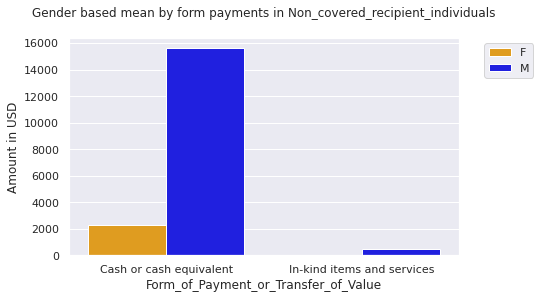

In [266]:
# gender based payments
create_chart_gender(NC_ind_gender_form_pay_avg, 'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD', 'Principal_Investigator_1_gender', 
                    'Gender based mean by form payments in Non_covered_recipient_individuals\n','Amount in USD')



In [275]:
# Total by gender based payments
NC_ind_gender_pay_median=NC_ind.groupby(['Principal_Investigator_1_gender'])['Dist_total_Payment_in_USD'].median().reset_index()

NC_ind_gender_pay_median

,Principal_Investigator_1_gender,Dist_total_Payment_in_USD
0,F,92.495
1,M,2558.500


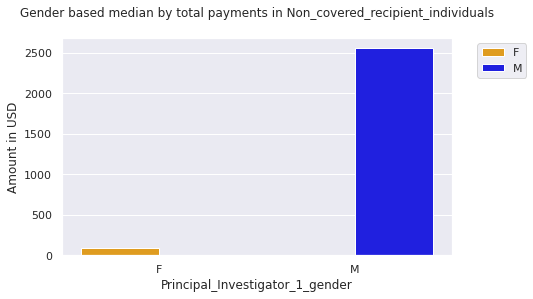

In [278]:
# gender based payments
create_chart_gender(NC_ind_gender_pay_median, 'Principal_Investigator_1_gender', 'Dist_total_Payment_in_USD', 'Principal_Investigator_1_gender', 
                    'Gender based median by total payments in Non_covered_recipient_individuals\n','Amount in USD')



In [279]:
# Total by gender based form of payments
NC_ind_gender_form_pay_median=NC_ind.groupby(['Principal_Investigator_1_gender','Form_of_Payment_or_Transfer_of_Value'])['Dist_total_Payment_in_USD'].median().reset_index()

NC_ind_gender_form_pay_median


,Principal_Investigator_1_gender,Form_of_Payment_or_Transfer_of_Value,Dist_total_Payment_in_USD
0,F,Cash or cash equivalent,92.495
1,M,Cash or cash equivalent,2736.500
2,M,In-kind items and services,501.150


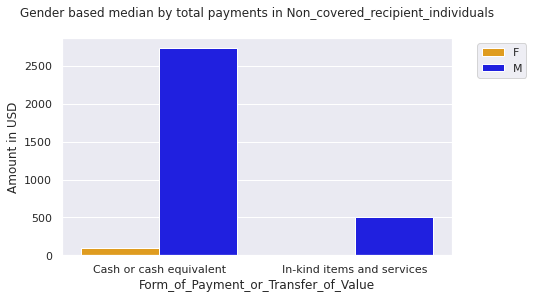

In [280]:
# gender based payments
create_chart_gender(NC_ind_gender_form_pay_median, 'Form_of_Payment_or_Transfer_of_Value', 'Dist_total_Payment_in_USD', 'Principal_Investigator_1_gender', 
                    'Gender based median by total payments in Non_covered_recipient_individuals\n','Amount in USD')



In [267]:
### Top companies list by payments, to be matched with lists we researched and submitted.


# Top paying companies
Paying_orgs=df_research.groupby(['Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name'])[['Total_Amount_of_Payment_USDollars']].sum()




In [268]:
print("Reasearch related payment by top 50 GPO or Manufacturing companies entire healthcare data")
Paying_orgs=Paying_orgs.sort_values(by=['Total_Amount_of_Payment_USDollars'], ascending=False)
print(Paying_orgs[:50])



Reasearch related payment by top 50 GPO or Manufacturing companies entire healthcare data
                                                    Total_Amount_of_Payment_USDollars
Applicable_Manufacturer_or_Applicable_GPO_Makin...                                   
modernatx, inc.                                                          7.412608e+08
pfizer inc.                                                              6.304575e+08
eli lilly and company                                                    5.773973e+08
merck sharp & dohme llc                                                  4.584203e+08
novartis pharmaceuticals corporation                                     3.747353e+08
genentech, inc.                                                          3.676896e+08
astrazeneca pharmaceuticals lp                                           3.311340e+08
janssen research & development, llc                                      2.517405e+08
abbvie inc.                                       

In [269]:
Paying_orgs.to_csv('top_research.csv')

Research payments made by companies in healthcare industry


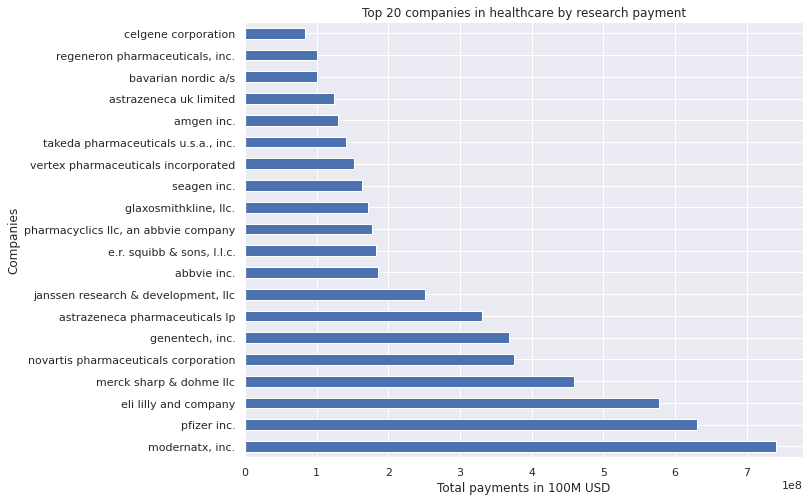

In [270]:
print("Research payments made by companies in healthcare industry")
ax = Paying_orgs[:20].plot(kind='barh',figsize=(10,8), legend=False)
ax.set_xlabel("Total payments in 100M USD")
ax.set_ylabel("Companies")
ax.set_title('Top 20 companies in healthcare by research payment');


# End

## This is industry level analysis and is based on analysis of all healthcare companies and sectors in research.